<a href="https://www.kaggle.com/code/lalit7881/comprehensive-car-market-eda?scriptVersionId=328801750" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lalit7881/comprehensive-car-market-analysis/v1-legacy-carapi-datafeed-sample.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/lalit7881/comprehensive-car-market-analysis/v1-legacy-carapi-datafeed-sample.csv")

In [3]:
df.head()

,Make Id,Make Name,Model Id,Model Name,Trim Id,Trim Year,Trim Name,Trim Description,Trim Msrp,Trim Invoice,...,Mileage Epa Highway Mpg,Mileage Range City,Mileage Range Highway,Mileage Epa Combined Mpg Electric,Mileage Epa City Mpg Electric,Mileage Epa Highway Mpg Electric,Mileage Range Electric,Mileage Epa Kwh 100 Mi Electric,Mileage Epa Time To Charge Hr 240v Electric,Mileage Battery Capacity Electric
0,1,Acura,97,ILX,6292,2020,Base,4dr Sedan (2.4L 4cyl 8AM),25900,24617.0,...,34.0,317.0,449.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Acura,97,ILX,6295,2020,Premium and A-SPEC Packages,Premium and A-SPEC Packages 4dr Sedan (2.4L 4c...,29750,28264.0,...,34.0,317.0,449.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,Acura,97,ILX,6293,2020,Premium Package,Premium Package 4dr Sedan (2.4L 4cyl 8AM),27750,26370.0,...,34.0,317.0,449.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,Acura,97,ILX,6296,2020,Technology and A-SPEC Packages,Technology and A-SPEC Packages 4dr Sedan (2.4L...,31650,30064.0,...,34.0,317.0,449.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,Acura,97,ILX,6294,2020,Technology Package,Technology Package 4dr Sedan (2.4L 4cyl 8AM),29650,28169.0,...,34.0,317.0,449.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,Make Id,Make Name,Model Id,Model Name,Trim Id,Trim Year,Trim Name,Trim Description,Trim Msrp,Trim Invoice,...,Mileage Epa Highway Mpg,Mileage Range City,Mileage Range Highway,Mileage Epa Combined Mpg Electric,Mileage Epa City Mpg Electric,Mileage Epa Highway Mpg Electric,Mileage Range Electric,Mileage Epa Kwh 100 Mi Electric,Mileage Epa Time To Charge Hr 240v Electric,Mileage Battery Capacity Electric
17702,23,Volvo,589,XC70,23951,2015,3.2,3.2 4dr Wagon AWD (3.2L 6cyl 6A),36900,34686.0,...,25.0,333.0,463.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17703,23,Volvo,589,XC70,23950,2015,T5 Drive-E,T5 Drive-E 4dr Wagon (2.0L 4cyl Turbo 8A),36050,33887.0,...,31.0,444.0,574.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17704,23,Volvo,589,XC70,23949,2015,T5 Drive-E,T5 Drive-E 4dr Wagon (2.0L 4cyl Turbo 8A),35400,33276.0,...,31.0,444.0,574.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17705,23,Volvo,589,XC70,23954,2015,T6,T6 4dr Wagon AWD (3.0L 6cyl Turbo 6A),42050,39527.0,...,24.0,315.0,444.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17706,23,Volvo,589,XC70,23953,2015,T6,T6 4dr Wagon AWD (3.0L 6cyl Turbo 6A),41800,39292.0,...,24.0,315.0,444.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17707 entries, 0 to 17706
Data columns (total 57 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Make Id                                      17707 non-null  int64  
 1   Make Name                                    17707 non-null  object 
 2   Model Id                                     17707 non-null  int64  
 3   Model Name                                   17707 non-null  object 
 4   Trim Id                                      17707 non-null  int64  
 5   Trim Year                                    17707 non-null  int64  
 6   Trim Name                                    17707 non-null  object 
 7   Trim Description                             17707 non-null  object 
 8   Trim Msrp                                    17707 non-null  int64  
 9   Trim Invoice                                 17704 non-null  float64
 10

In [6]:
df.describe()

,Make Id,Model Id,Trim Id,Trim Year,Trim Msrp,Trim Invoice,Engine Id,Engine Size,Engine Horsepower Hp,Engine Horsepower Rpm,...,Mileage Epa Highway Mpg,Mileage Range City,Mileage Range Highway,Mileage Epa Combined Mpg Electric,Mileage Epa City Mpg Electric,Mileage Epa Highway Mpg Electric,Mileage Range Electric,Mileage Epa Kwh 100 Mi Electric,Mileage Epa Time To Charge Hr 240v Electric,Mileage Battery Capacity Electric
count,17707.000000,17707.000000,17707.000000,17707.000000,1.770700e+04,17704.000000,17673.000000,17452.000000,17531.000000,17147.000000,...,14565.000000,17449.000000,17449.000000,462.000000,389.000000,389.000000,325.000000,299.000000,316.000000,161.000000
mean,20.042413,275.892133,15329.854916,2017.514655,4.854835e+04,39881.853479,15159.662197,3.481423,291.791113,5771.823001,...,27.946447,305.924867,413.428678,89.807359,96.192802,87.591260,106.766154,40.301003,5.139241,48.639752
std,12.748010,209.868165,6538.017344,1.694286,4.408983e+04,25761.988991,5306.128616,1.541130,109.890596,713.986235,...,6.673848,156.765174,208.121077,25.288781,29.979226,21.410929,113.190790,13.686925,3.551192,29.401861
min,1.000000,2.000000,6292.000000,2015.000000,0.000000e+00,0.000000,6292.000000,0.600000,66.000000,2800.000000,...,11.000000,0.000000,0.000000,39.000000,34.000000,37.000000,9.000000,24.000000,1.300000,1.000000
25%,8.000000,167.000000,10718.500000,2016.000000,3.048000e+04,27235.750000,10710.000000,2.000000,200.000000,5500.000000,...,23.000000,296.000000,406.000000,68.000000,68.000000,70.000000,19.000000,30.000000,2.700000,25.000000
50%,19.000000,267.000000,15145.000000,2018.000000,3.933500e+04,35931.500000,15128.000000,3.500000,285.000000,5750.000000,...,27.000000,348.000000,475.000000,97.000000,101.000000,93.000000,32.000000,33.000000,3.000000,38.000000
75%,29.000000,379.000000,19572.500000,2019.000000,5.104500e+04,46011.000000,19547.000000,4.400000,360.000000,6300.000000,...,32.000000,391.000000,537.000000,110.000000,124.000000,103.000000,215.000000,49.000000,8.125000,75.000000
max,56.000000,5024.000000,101978.000000,2020.000000,1.990064e+06,836100.000000,78461.000000,8.400000,1001.000000,9000.000000,...,354.000000,790.000000,900.000000,141.000000,150.000000,132.000000,402.000000,80.000000,15.300000,103.000000


In [7]:
df.isnull()

,Make Id,Make Name,Model Id,Model Name,Trim Id,Trim Year,Trim Name,Trim Description,Trim Msrp,Trim Invoice,...,Mileage Epa Highway Mpg,Mileage Range City,Mileage Range Highway,Mileage Epa Combined Mpg Electric,Mileage Epa City Mpg Electric,Mileage Epa Highway Mpg Electric,Mileage Range Electric,Mileage Epa Kwh 100 Mi Electric,Mileage Epa Time To Charge Hr 240v Electric,Mileage Battery Capacity Electric
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17702,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
17703,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
17704,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True
17705,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,True,True,True,True,True


In [8]:
df.isnull().sum()

Make Id                                            0
Make Name                                          0
Model Id                                           0
Model Name                                         0
Trim Id                                            0
Trim Year                                          0
Trim Name                                          0
Trim Description                                   0
Trim Msrp                                          0
Trim Invoice                                       3
Trim Created                                       0
Trim Modified                                      0
Engine Id                                         34
Engine Type                                       34
Engine Fuel Type                                  34
Engine Cylinders                                 255
Engine Size                                      255
Engine Horsepower Hp                             176
Engine Horsepower Rpm                         

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Make Id                                          int64
Make Name                                       object
Model Id                                         int64
Model Name                                      object
Trim Id                                          int64
Trim Year                                        int64
Trim Name                                       object
Trim Description                                object
Trim Msrp                                        int64
Trim Invoice                                   float64
Trim Created                                    object
Trim Modified                                   object
Engine Id                                      float64
Engine Type                                     object
Engine Fuel Type                                object
Engine Cylinders                                object
Engine Size                                    float64
Engine Horsepower Hp                           float64
Engine Hor

In [11]:
df.shape

(17707, 57)

In [12]:
df.columns

Index(['Make Id', 'Make Name', 'Model Id', 'Model Name', 'Trim Id',
       'Trim Year', 'Trim Name', 'Trim Description', 'Trim Msrp',
       'Trim Invoice', 'Trim Created', 'Trim Modified', 'Engine Id',
       'Engine Type', 'Engine Fuel Type', 'Engine Cylinders', 'Engine Size',
       'Engine Horsepower Hp', 'Engine Horsepower Rpm', 'Engine Torque Ft Lbs',
       'Engine Torque Rpm', 'Engine Valves', 'Engine Valve Timing',
       'Engine Cam Type', 'Engine Drive Type', 'Engine Transmission',
       'Body Id', 'Body Type', 'Body Doors', 'Body Seats', 'Body Length',
       'Body Width', 'Body Height', 'Body Wheel Base', 'Body Front Track',
       'Body Rear Track', 'Body Ground Clearance', 'Body Cargo Capacity',
       'Body Max Cargo Capacity', 'Body Curb Weight', 'Body Gross Weight',
       'Body Max Payload', 'Body Max Towing Capacity', 'Mileage Id',
       'Mileage Fuel Tank Capacity', 'Mileage Combined Mpg',
       'Mileage Epa City Mpg', 'Mileage Epa Highway Mpg', 'Mileage Range C

In [13]:
df.nunique()

Make Id                                           46
Make Name                                         46
Model Id                                         551
Model Name                                       549
Trim Id                                        17707
Trim Year                                          6
Trim Name                                       1809
Trim Description                                6809
Trim Msrp                                       7199
Trim Invoice                                   12386
Trim Created                                      41
Trim Modified                                     41
Engine Id                                      17673
Engine Type                                        9
Engine Fuel Type                                  12
Engine Cylinders                                  13
Engine Size                                       53
Engine Horsepower Hp                             359
Engine Horsepower Rpm                         

## EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17707 entries, 0 to 17706
Data columns (total 57 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Make Id                                      17707 non-null  int64  
 1   Make Name                                    17707 non-null  object 
 2   Model Id                                     17707 non-null  int64  
 3   Model Name                                   17707 non-null  object 
 4   Trim Id                                      17707 non-null  int64  
 5   Trim Year                                    17707 non-null  int64  
 6   Trim Name                                    17707 non-null  object 
 7   Trim Description                             17707 non-null  object 
 8   Trim Msrp                                    17707 non-null  int64  
 9   Trim Invoice                                 17704 non-null  float64
 10

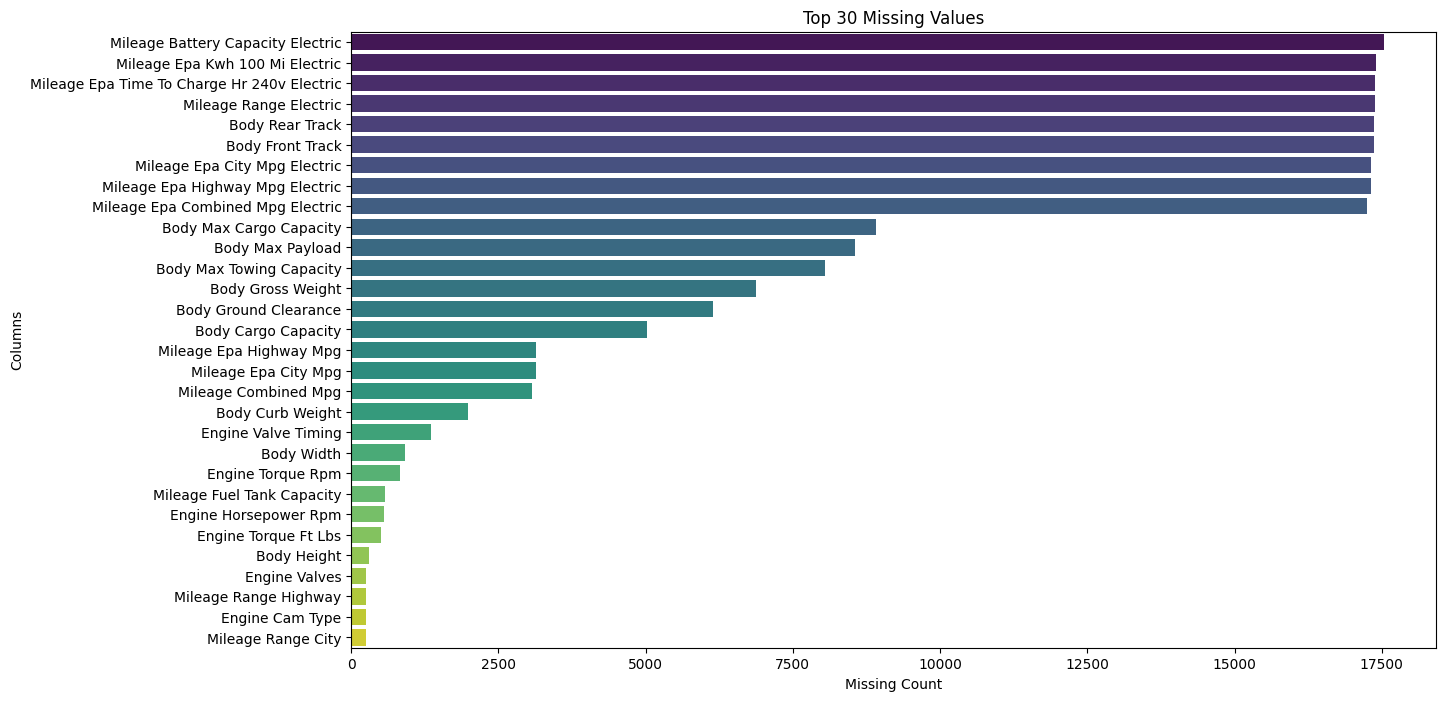

Numerical Features: 43


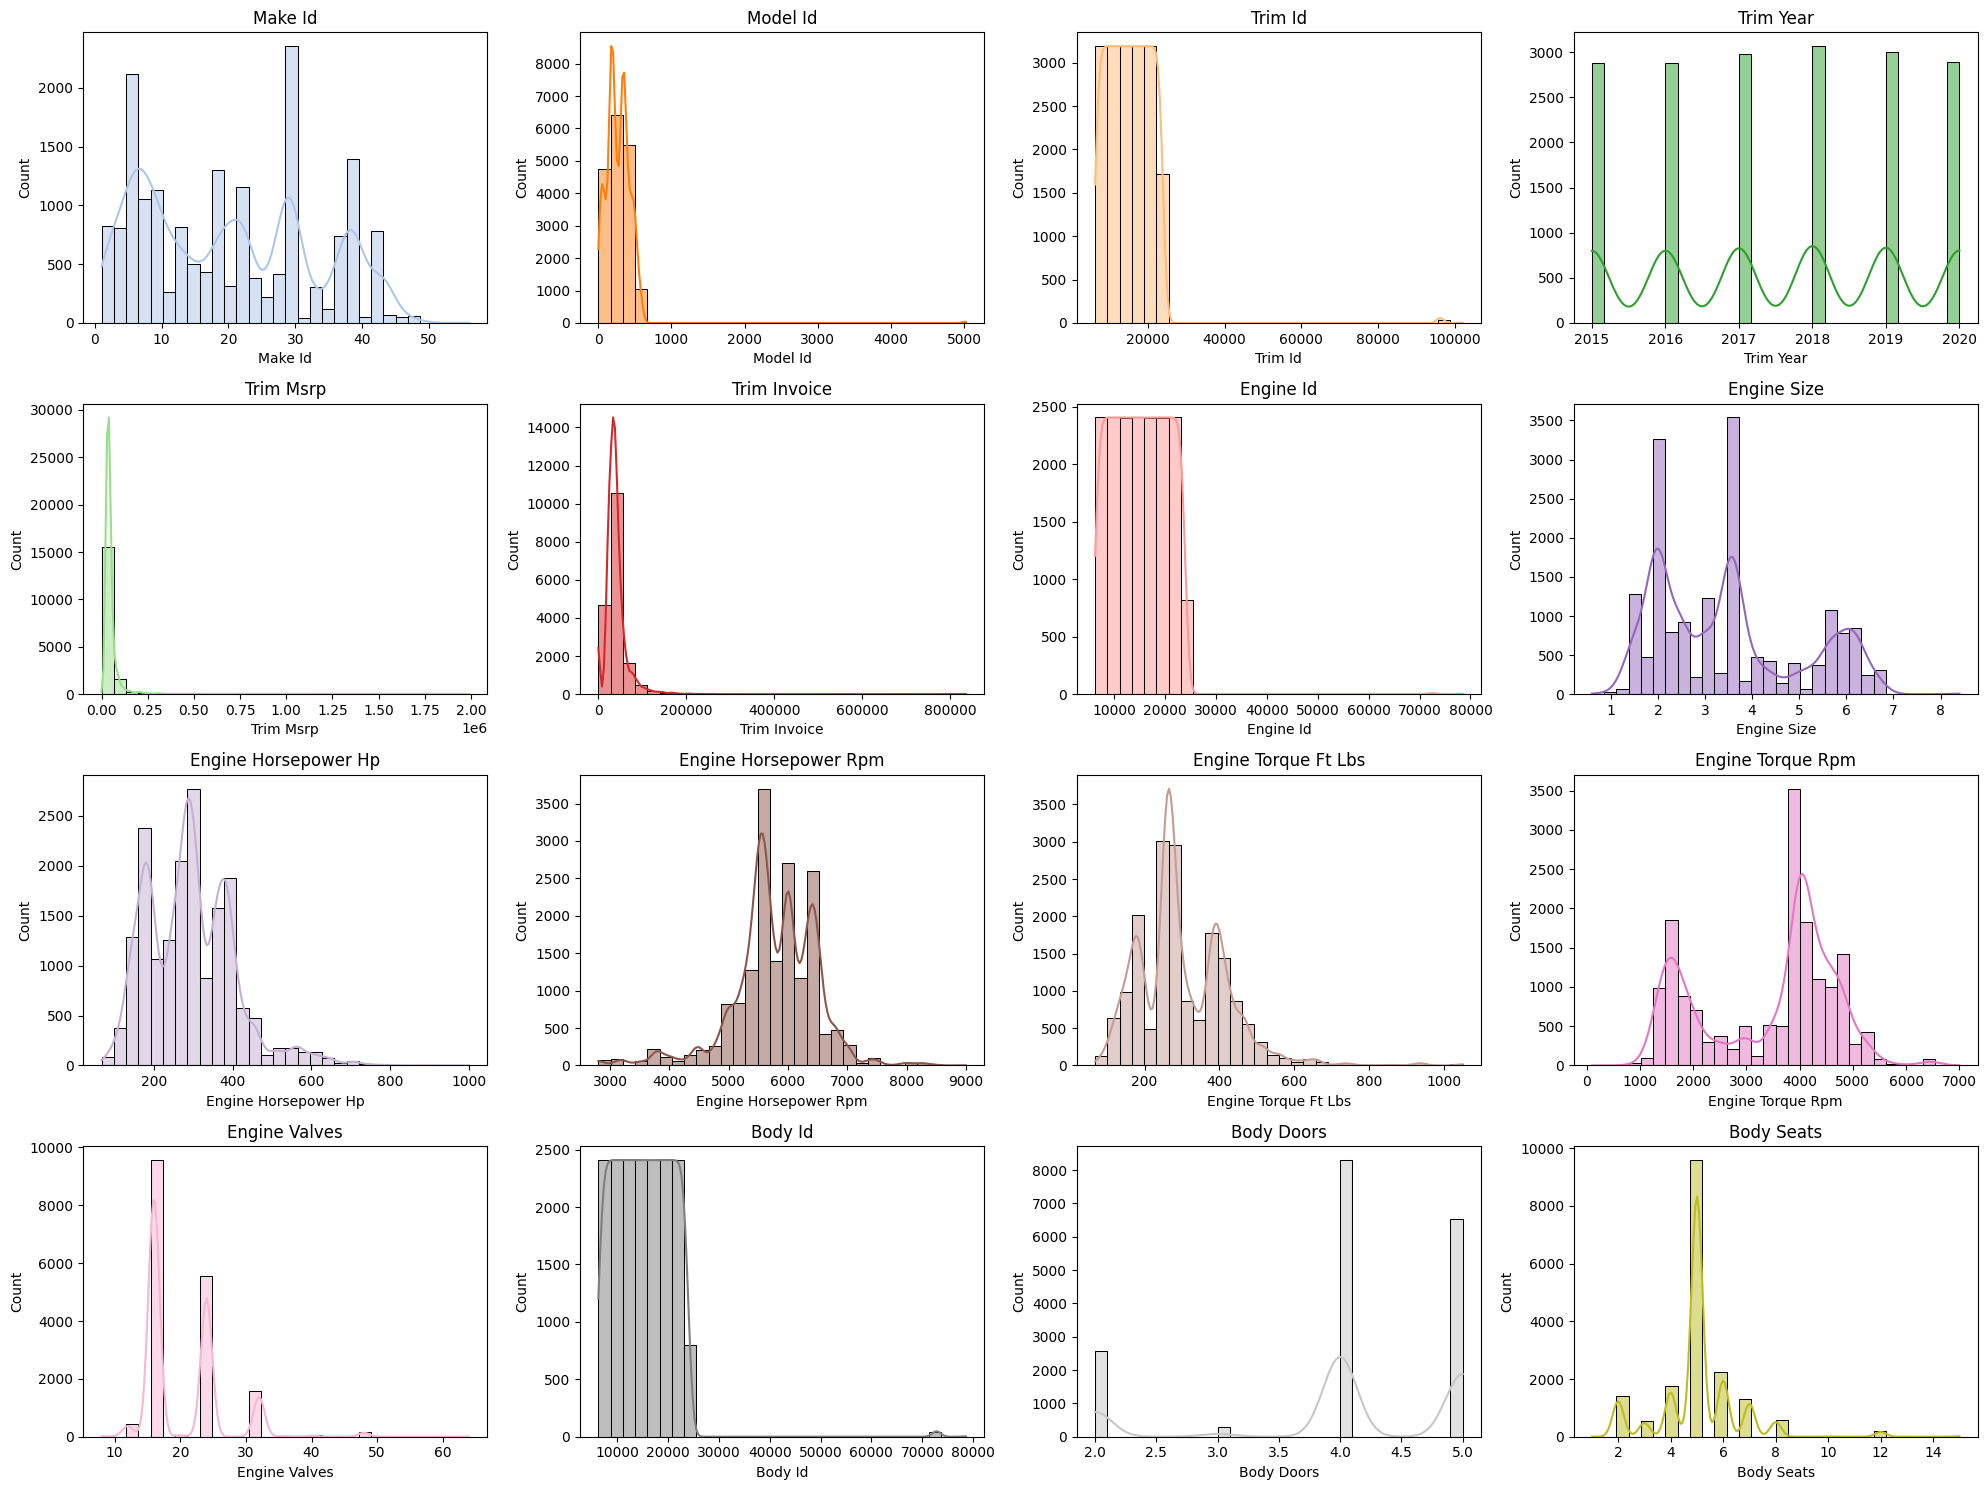

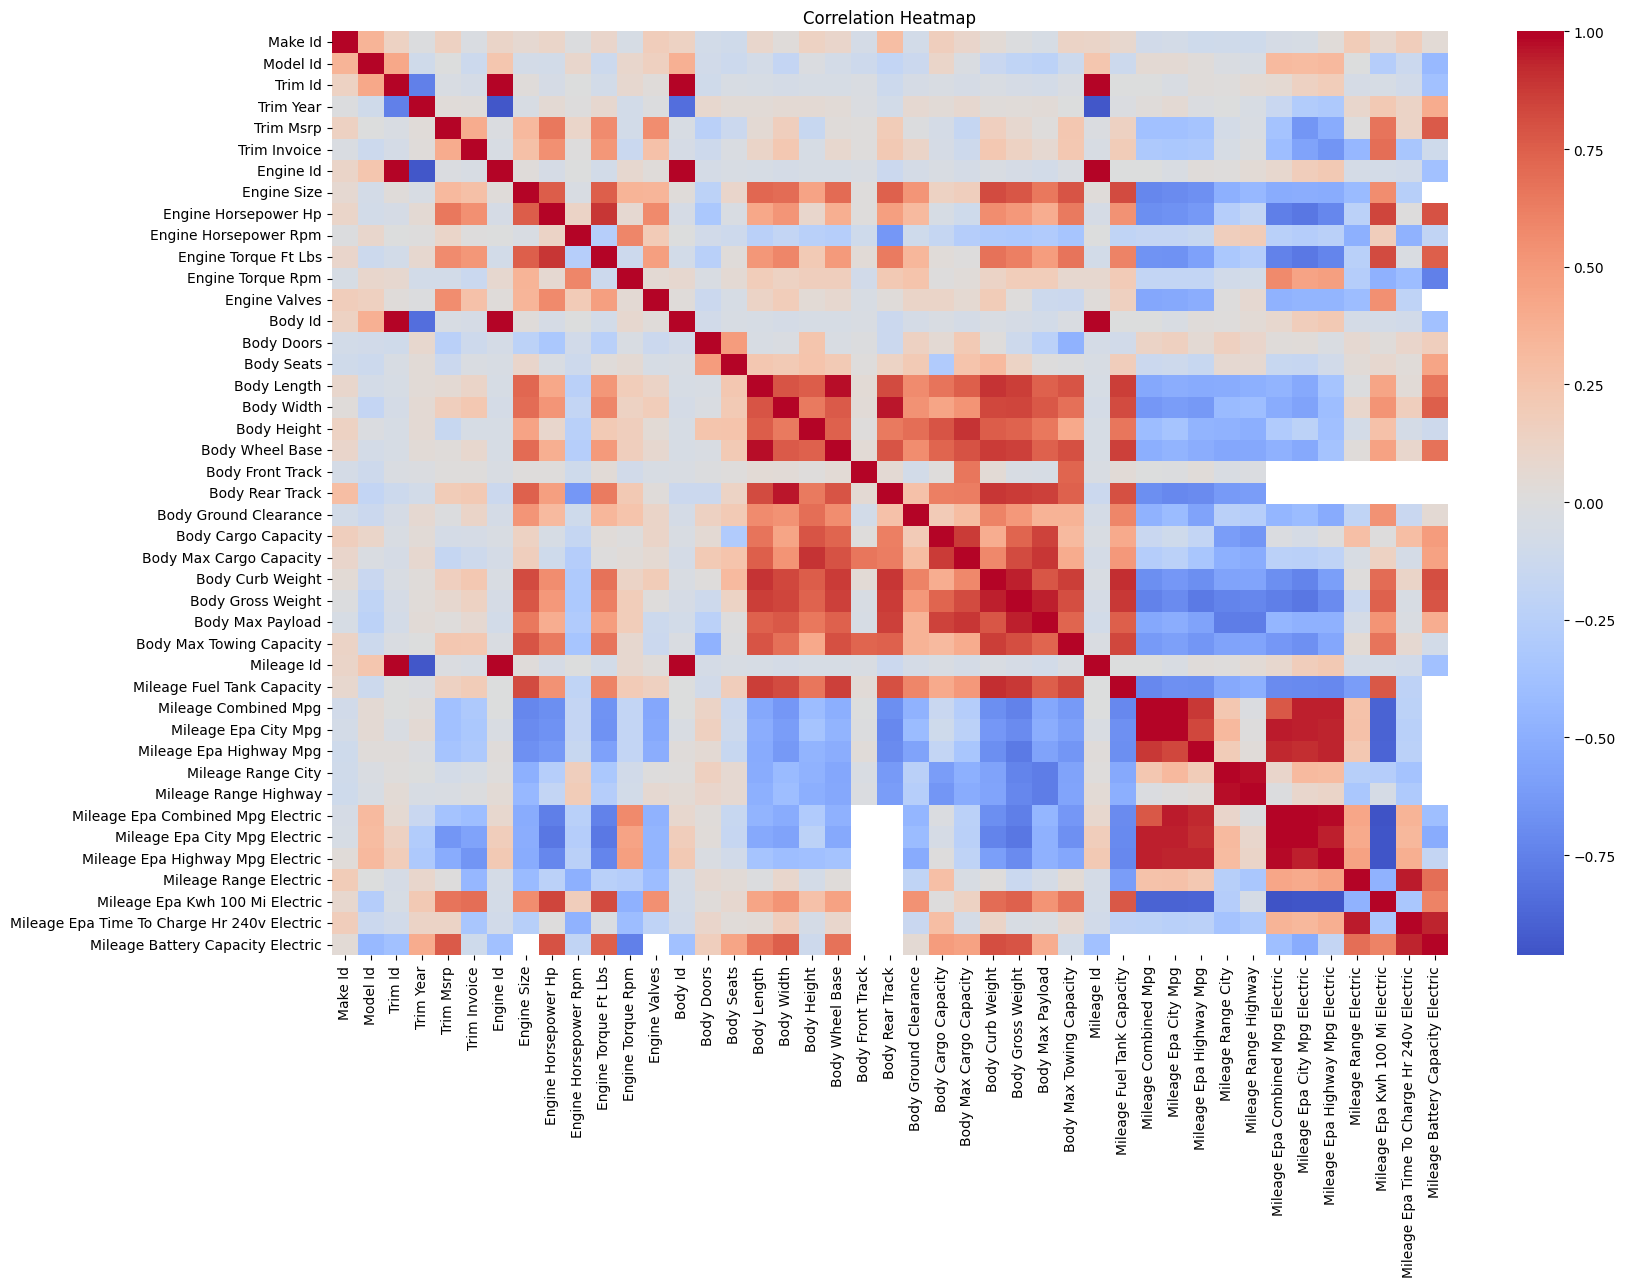

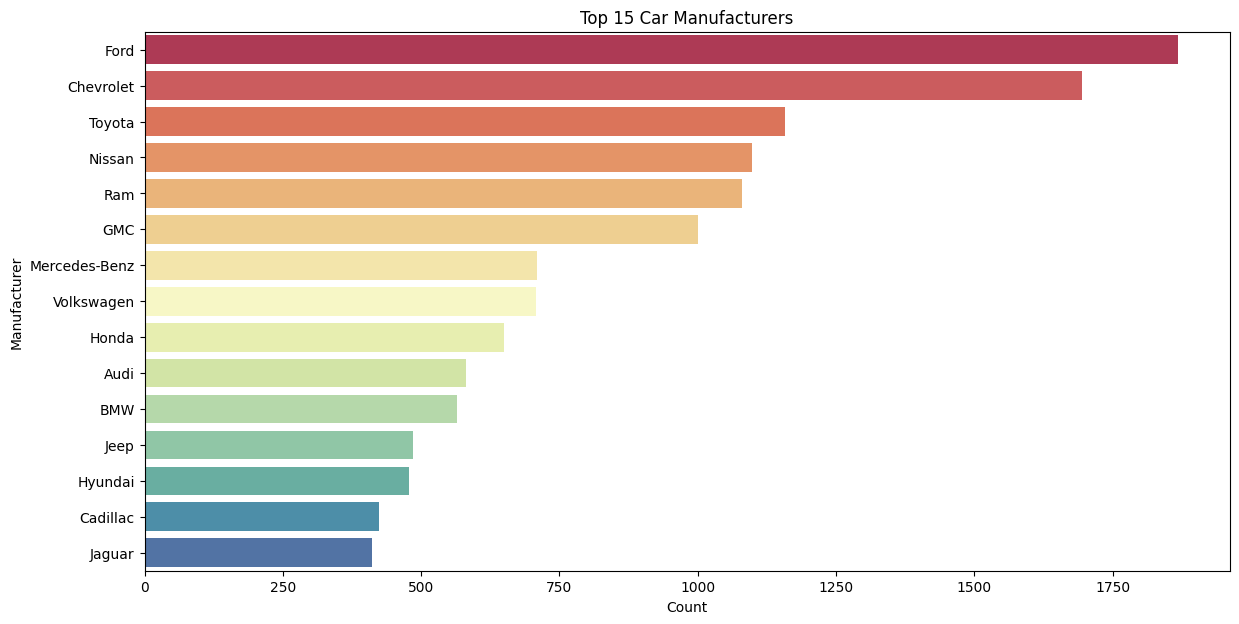

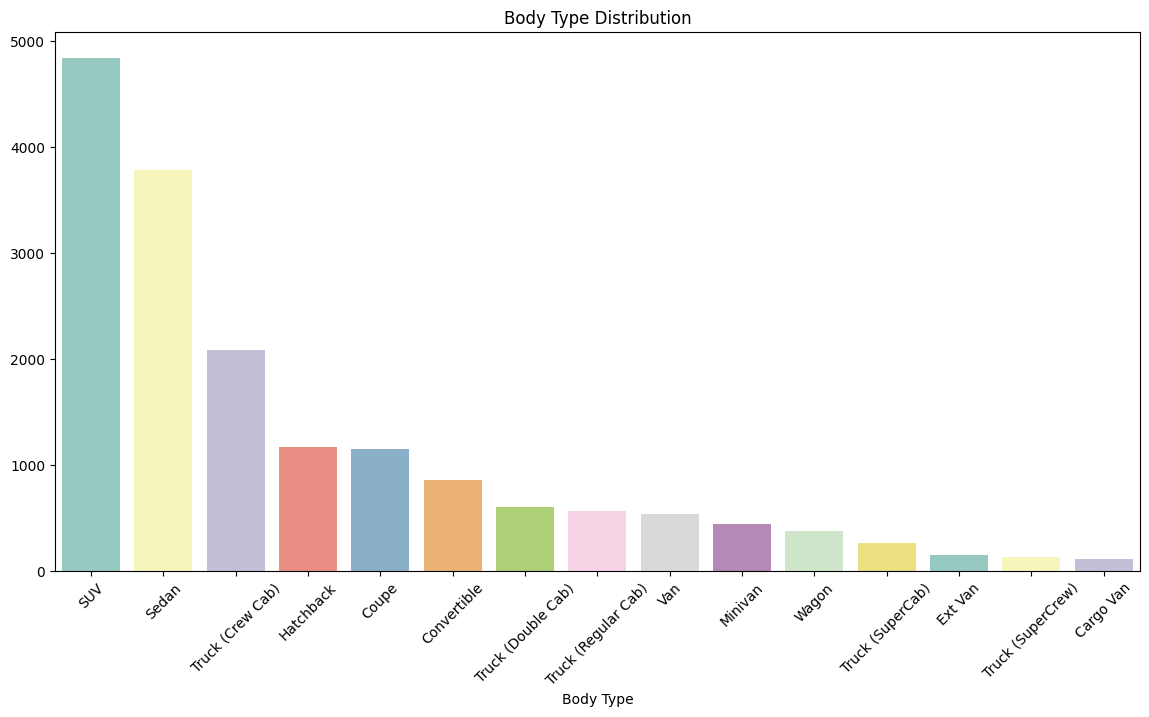

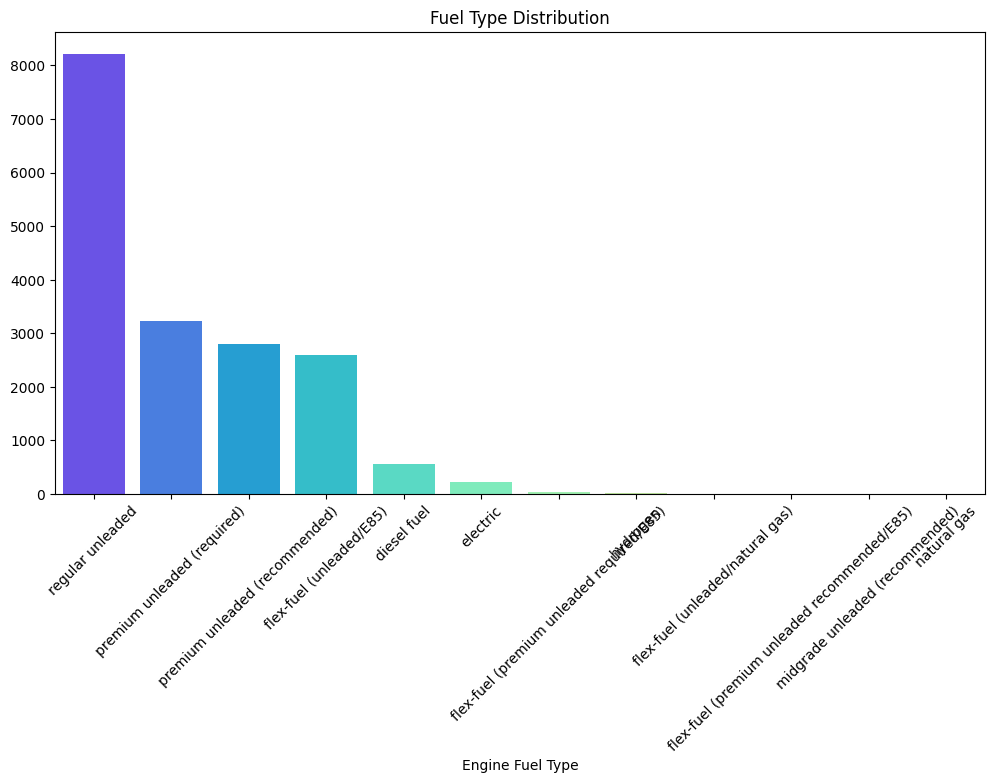

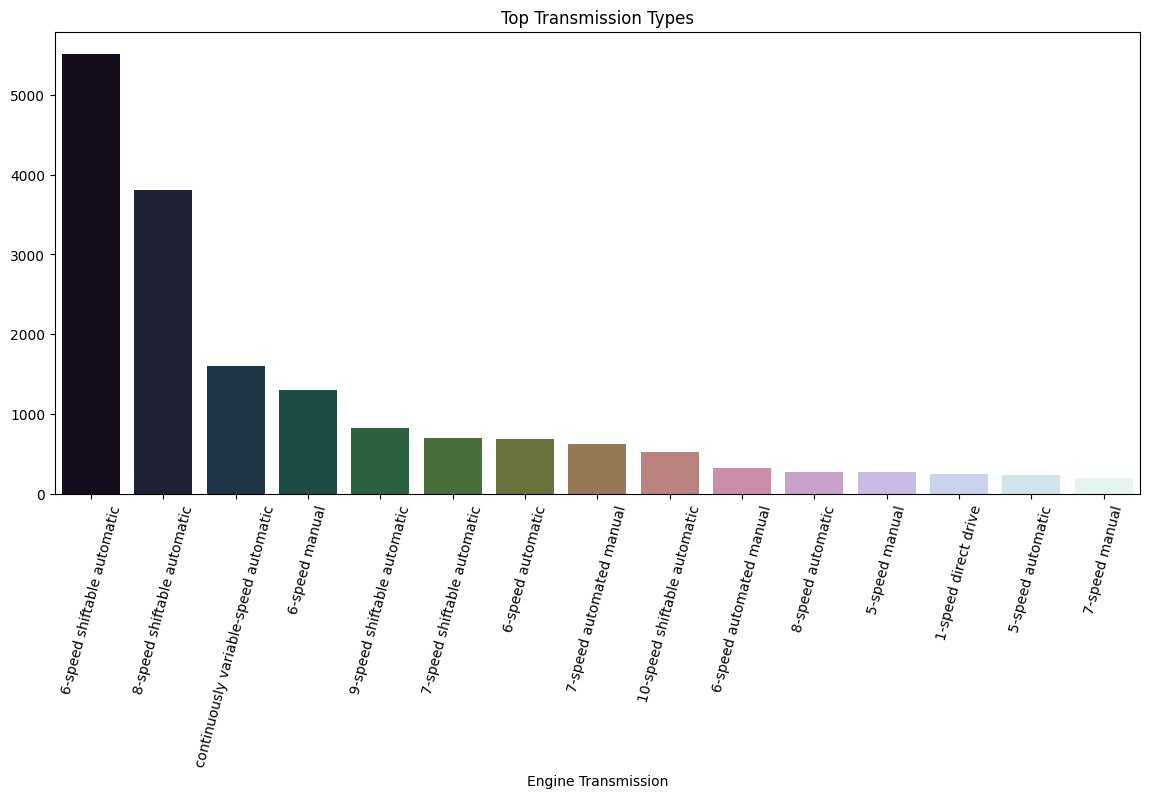

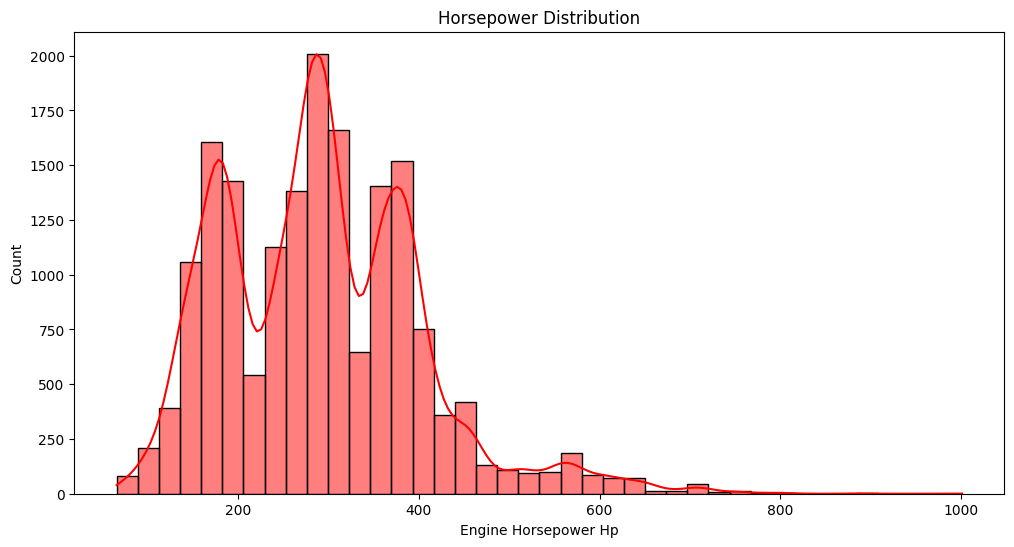

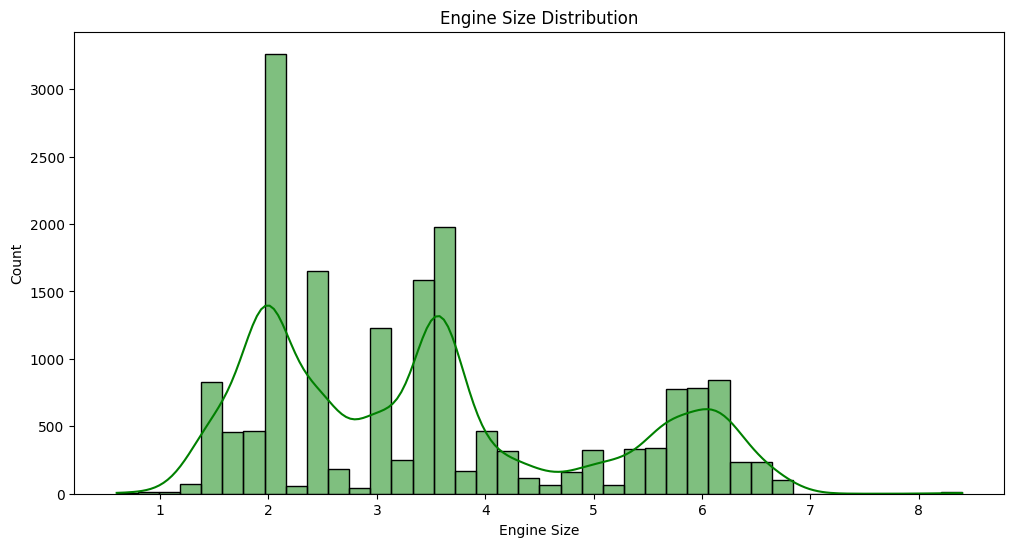

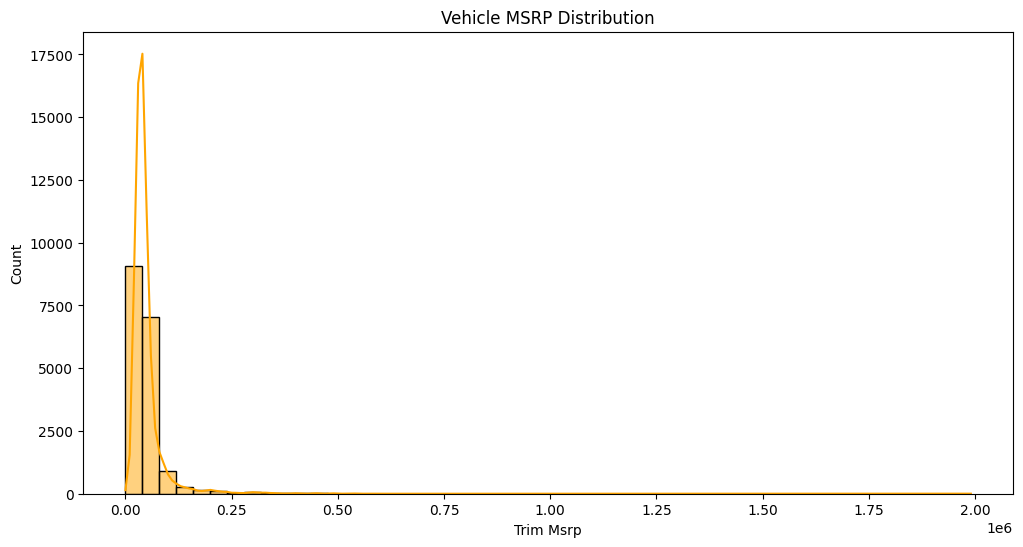

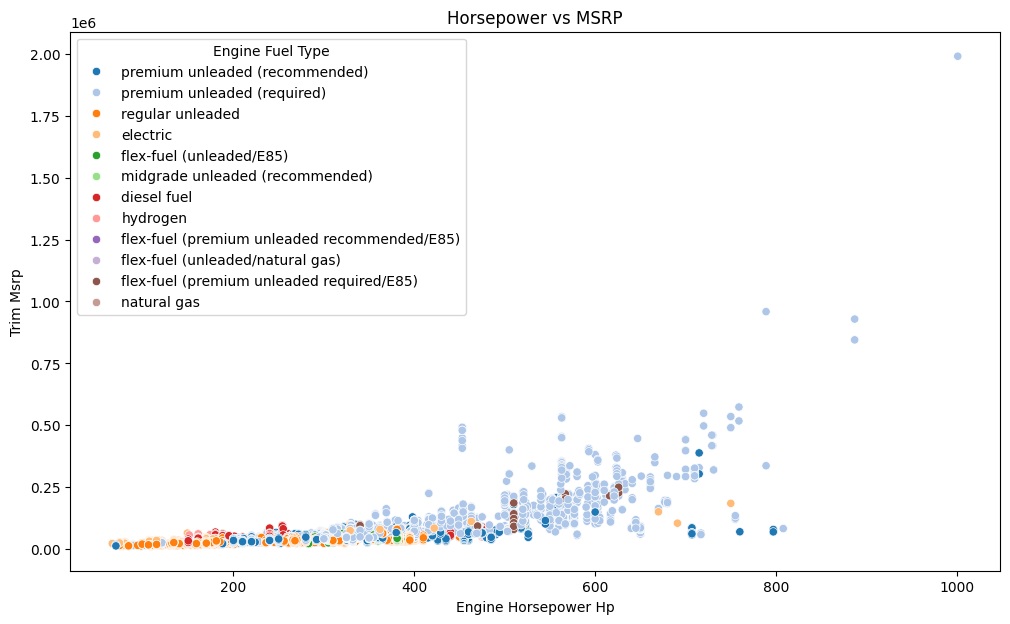

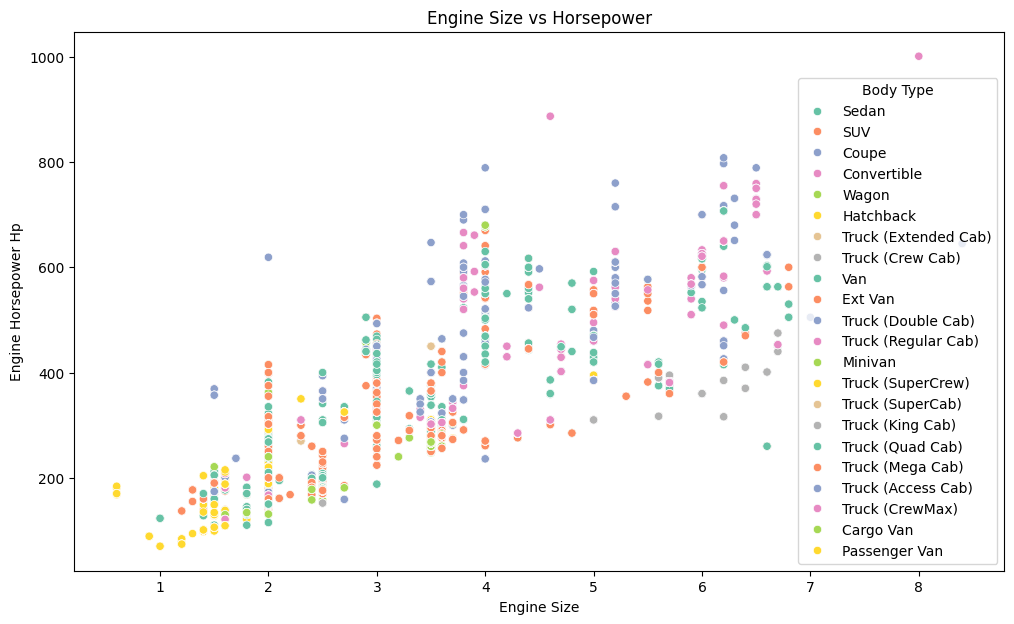

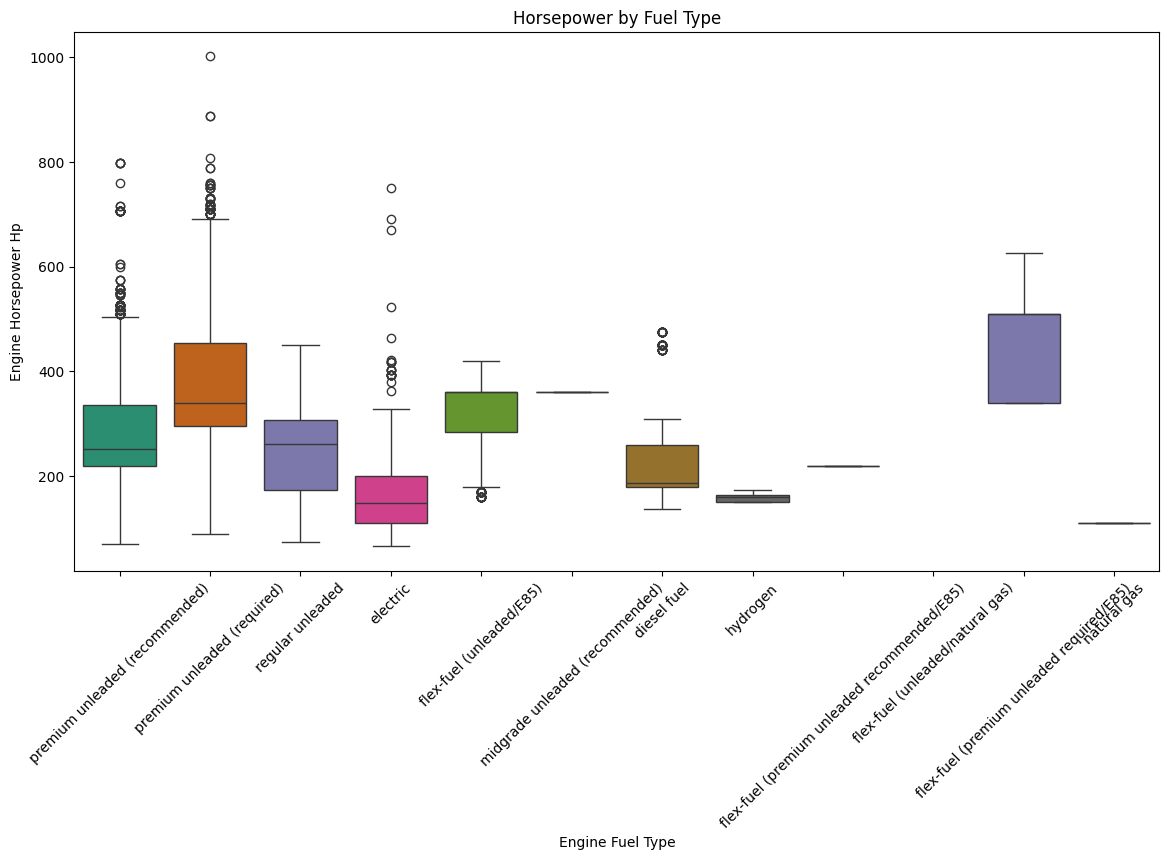

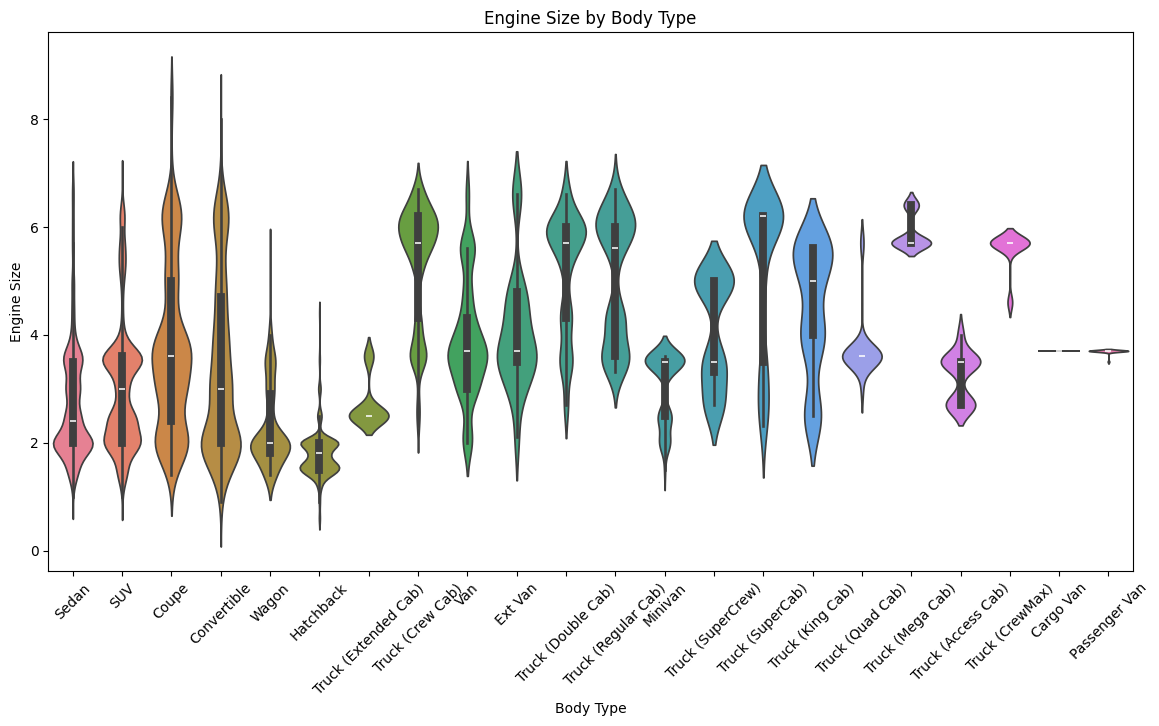

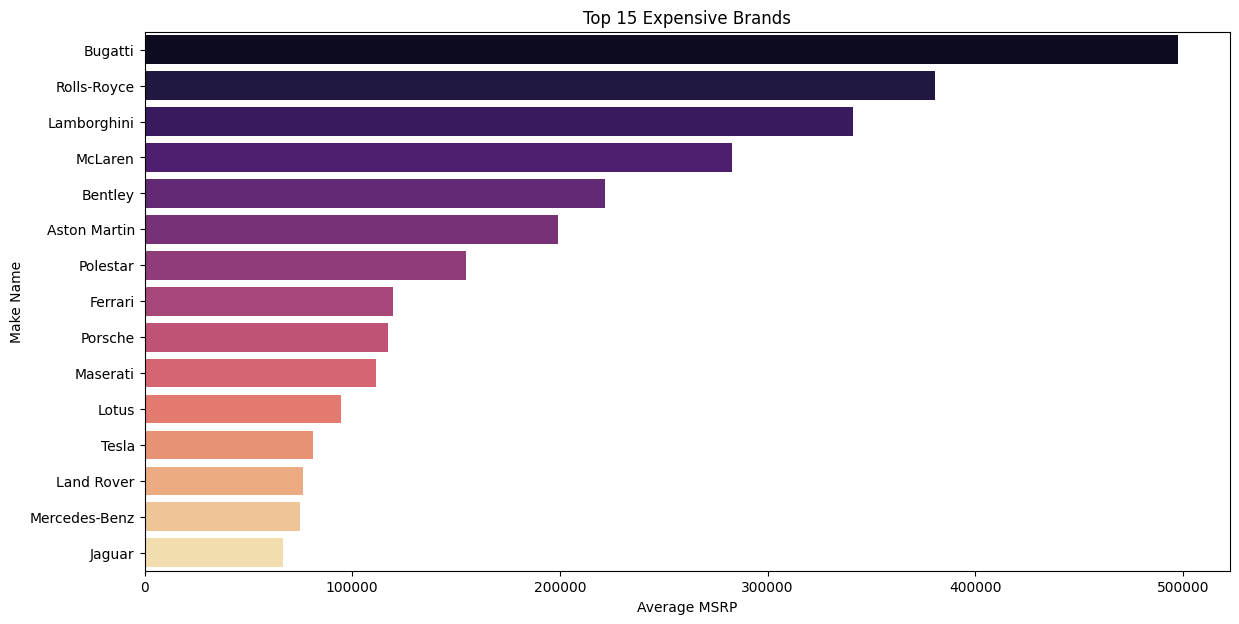

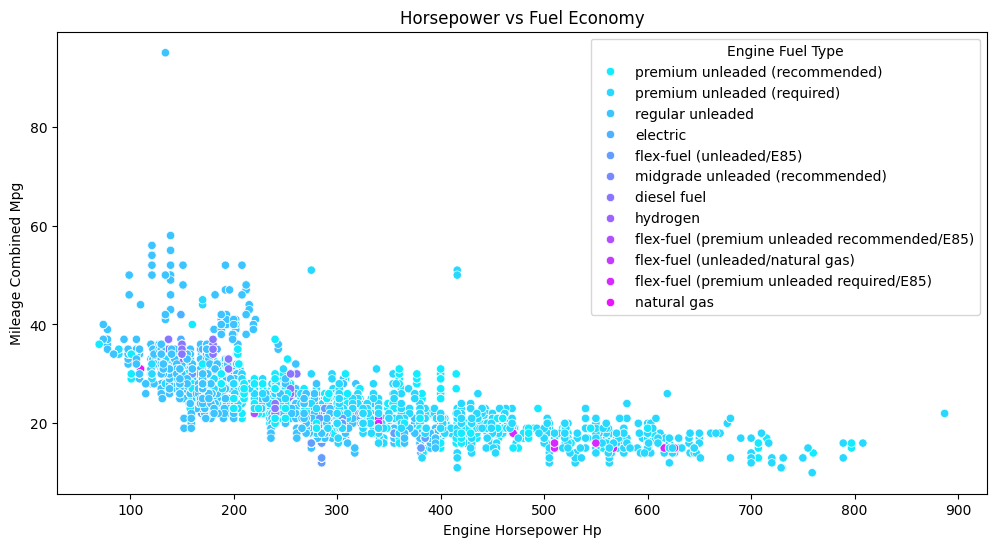

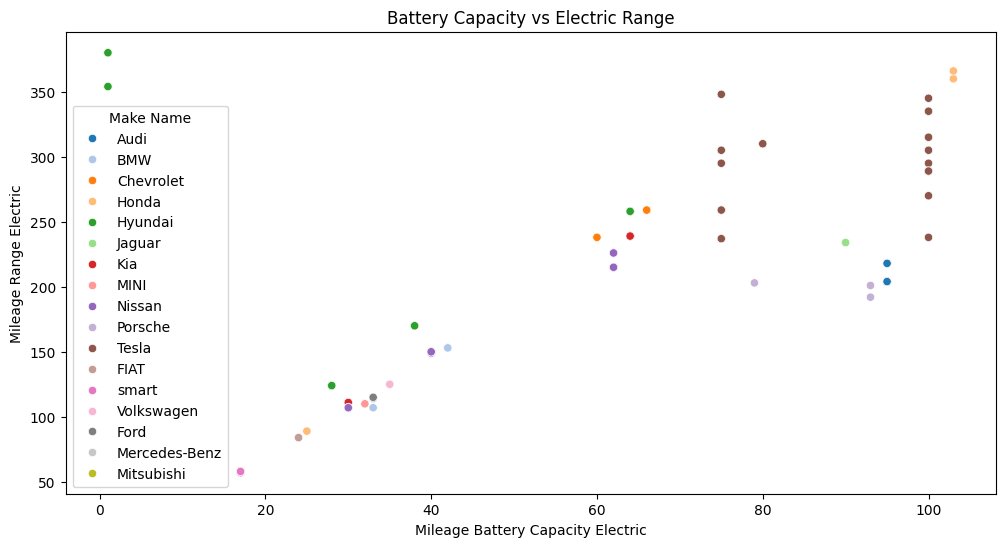

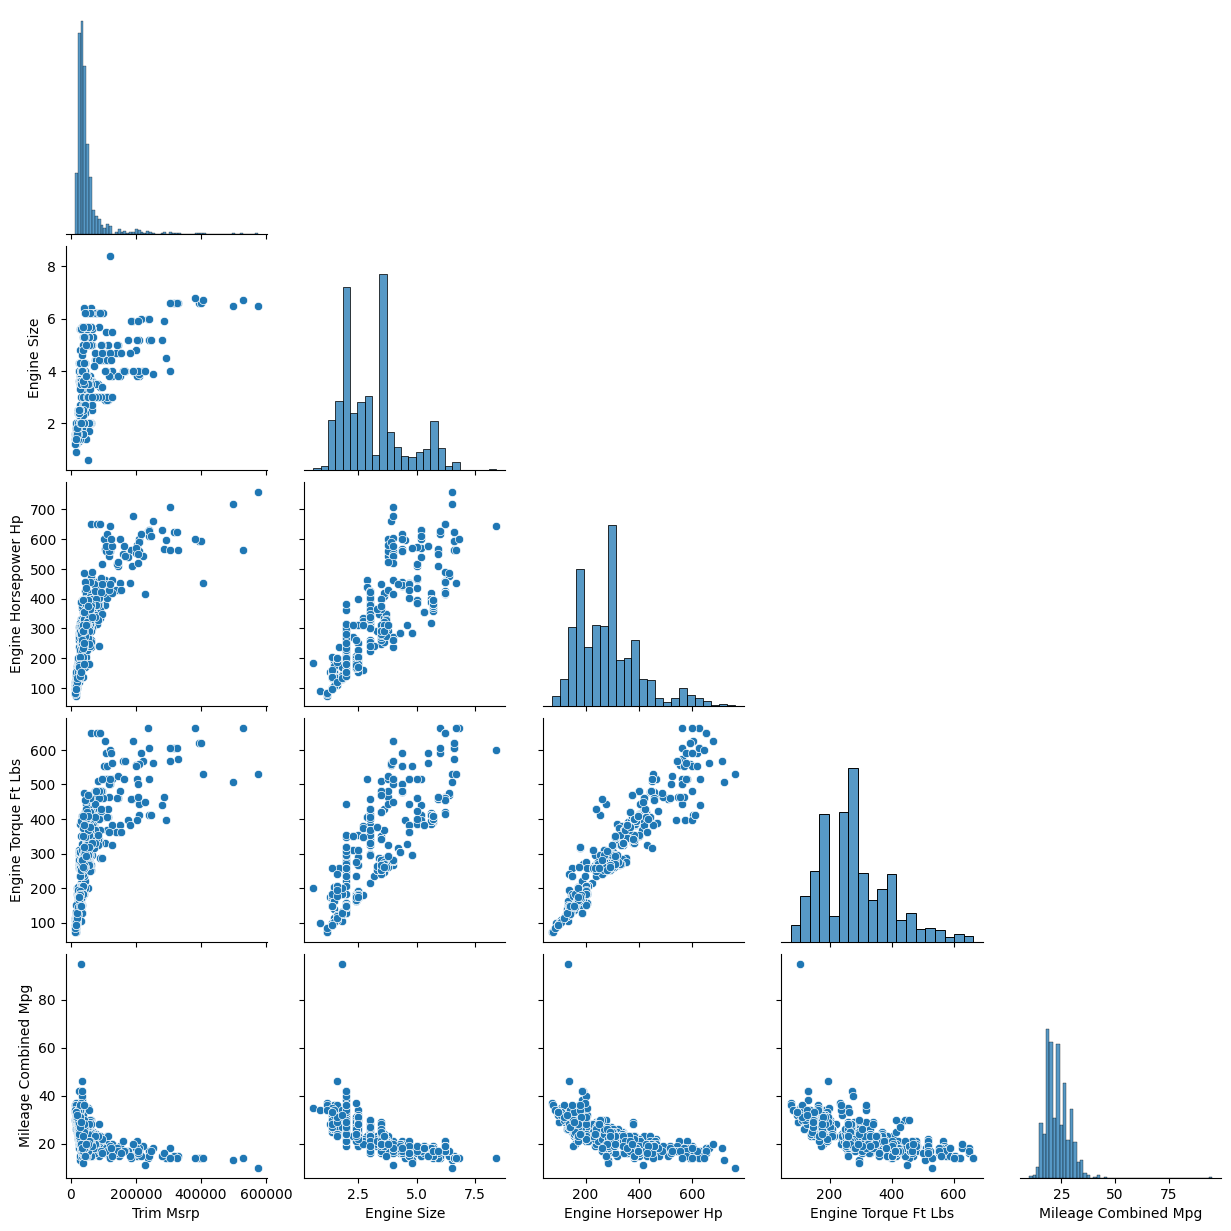

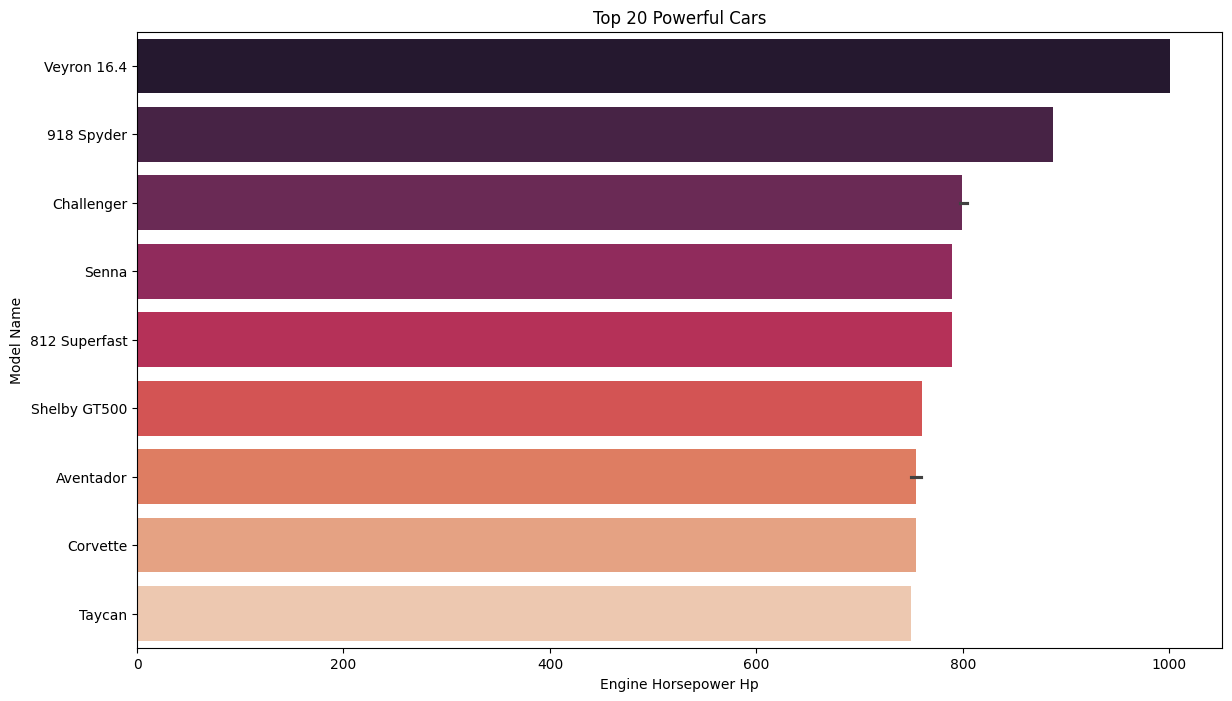

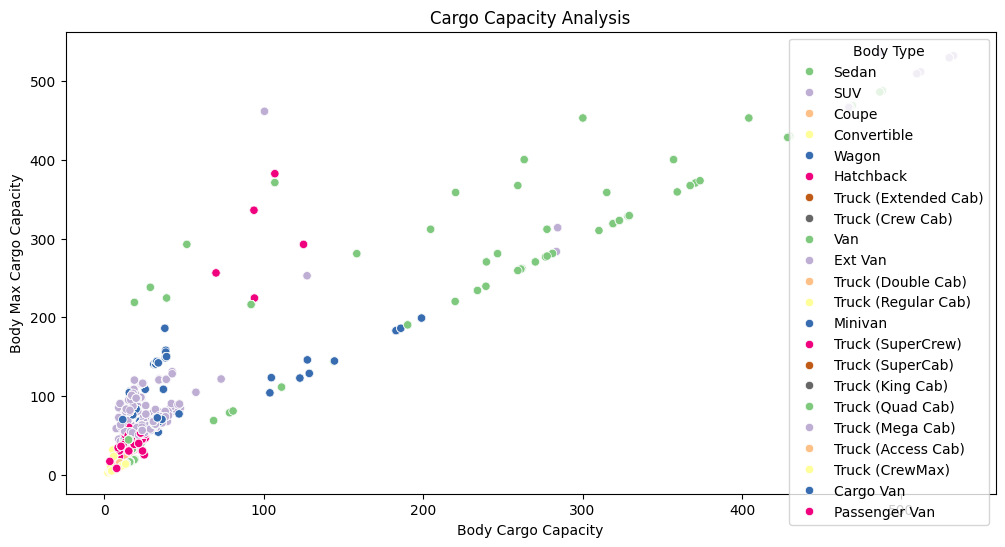

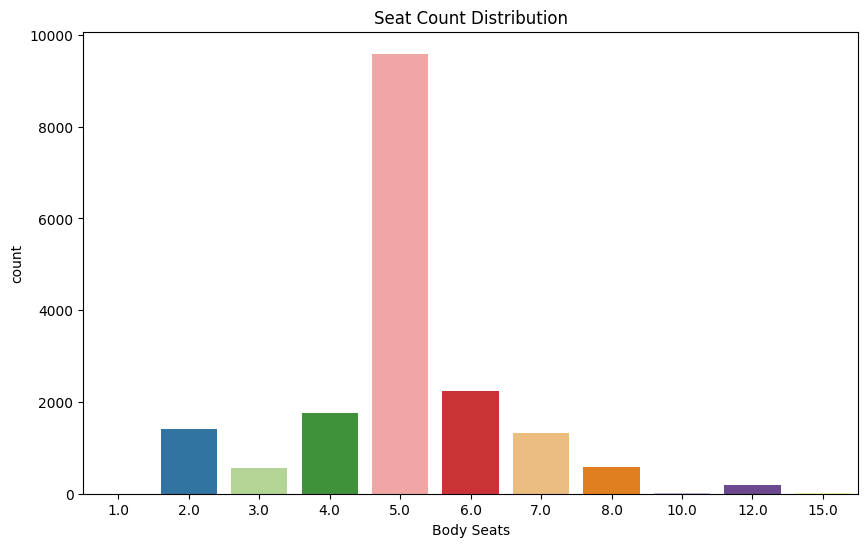

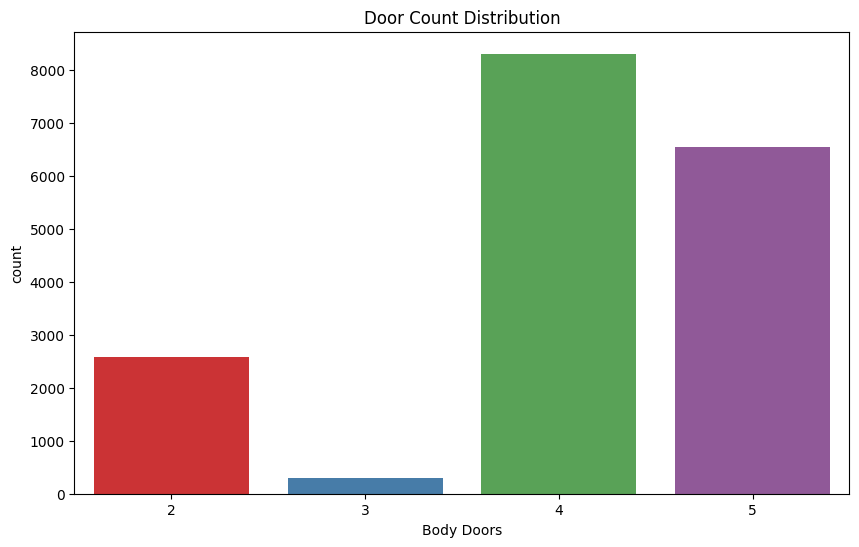

Visualization Completed Successfully


In [14]:
print(df.info())

# ------------------------------------------
# MISSING VALUES
# ------------------------------------------

missing = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(14,8))
sns.barplot(
    x=missing.values[:30],
    y=missing.index[:30],
    palette="viridis"
)

plt.title("Top 30 Missing Values")
plt.xlabel("Missing Count")
plt.ylabel("Columns")
plt.show()

# ==========================================
# NUMERICAL FEATURES
# ==========================================

num_cols = df.select_dtypes(include=np.number).columns

print("Numerical Features:", len(num_cols))

# ------------------------------------------
# HISTOGRAMS
# ------------------------------------------

plt.figure(figsize=(20,15))

for i,col in enumerate(num_cols[:16],1):

    plt.subplot(4,4,i)

    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        color=plt.cm.tab20(i)
    )

    plt.title(col)

plt.tight_layout()
plt.show()

# ==========================================
# CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(18,12))

corr = df[num_cols].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

# ==========================================
# TOP CAR MAKES
# ==========================================

top_makes = df['Make Name'].value_counts().head(15)

plt.figure(figsize=(14,7))

sns.barplot(
    x=top_makes.values,
    y=top_makes.index,
    palette="Spectral"
)

plt.title("Top 15 Car Manufacturers")
plt.xlabel("Count")
plt.ylabel("Manufacturer")
plt.show()

# ==========================================
# BODY TYPE DISTRIBUTION
# ==========================================

plt.figure(figsize=(14,7))

body_counts = df['Body Type'].value_counts().head(15)

sns.barplot(
    x=body_counts.index,
    y=body_counts.values,
    palette="Set3"
)

plt.xticks(rotation=45)
plt.title("Body Type Distribution")
plt.show()

# ==========================================
# ENGINE FUEL TYPE
# ==========================================

plt.figure(figsize=(12,6))

fuel_counts = df['Engine Fuel Type'].value_counts()

sns.barplot(
    x=fuel_counts.index,
    y=fuel_counts.values,
    palette="rainbow"
)

plt.xticks(rotation=45)
plt.title("Fuel Type Distribution")
plt.show()

# ==========================================
# TRANSMISSION ANALYSIS
# ==========================================

plt.figure(figsize=(14,6))

trans = df['Engine Transmission'].value_counts().head(15)

sns.barplot(
    x=trans.index,
    y=trans.values,
    palette="cubehelix"
)

plt.xticks(rotation=75)
plt.title("Top Transmission Types")
plt.show()

# ==========================================
# HORSEPOWER DISTRIBUTION
# ==========================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['Engine Horsepower Hp'],
    bins=40,
    kde=True,
    color='red'
)

plt.title("Horsepower Distribution")
plt.show()

# ==========================================
# ENGINE SIZE DISTRIBUTION
# ==========================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['Engine Size'],
    bins=40,
    kde=True,
    color='green'
)

plt.title("Engine Size Distribution")
plt.show()

# ==========================================
# MSRP DISTRIBUTION
# ==========================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['Trim Msrp'],
    bins=50,
    kde=True,
    color='orange'
)

plt.title("Vehicle MSRP Distribution")
plt.show()

# ==========================================
# HORSEPOWER VS MSRP
# ==========================================

plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df,
    x='Engine Horsepower Hp',
    y='Trim Msrp',
    hue='Engine Fuel Type',
    palette='tab20'
)

plt.title("Horsepower vs MSRP")
plt.show()

# ==========================================
# ENGINE SIZE VS HORSEPOWER
# ==========================================

plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df,
    x='Engine Size',
    y='Engine Horsepower Hp',
    hue='Body Type',
    palette='Set2'
)

plt.title("Engine Size vs Horsepower")
plt.show()

# ==========================================
# BOXPLOT
# ==========================================

plt.figure(figsize=(14,7))

sns.boxplot(
    data=df,
    x='Engine Fuel Type',
    y='Engine Horsepower Hp',
    palette='Dark2'
)

plt.xticks(rotation=45)
plt.title("Horsepower by Fuel Type")
plt.show()

# ==========================================
# VIOLIN PLOT
# ==========================================

plt.figure(figsize=(14,7))

sns.violinplot(
    data=df,
    x='Body Type',
    y='Engine Size',
    palette='husl'
)

plt.xticks(rotation=45)
plt.title("Engine Size by Body Type")
plt.show()

# ==========================================
# TOP EXPENSIVE BRANDS
# ==========================================

brand_price = (
    df.groupby('Make Name')['Trim Msrp']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,7))

sns.barplot(
    x=brand_price.values,
    y=brand_price.index,
    palette='magma'
)

plt.title("Top 15 Expensive Brands")
plt.xlabel("Average MSRP")
plt.show()

# ==========================================
# FUEL ECONOMY ANALYSIS
# ==========================================

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='Engine Horsepower Hp',
    y='Mileage Combined Mpg',
    hue='Engine Fuel Type',
    palette='cool'
)

plt.title("Horsepower vs Fuel Economy")
plt.show()

# ==========================================
# ELECTRIC VEHICLE ANALYSIS
# ==========================================

ev = df[
    df['Mileage Battery Capacity Electric'].notnull()
]

if len(ev) > 0:

    plt.figure(figsize=(12,6))

    sns.scatterplot(
        data=ev,
        x='Mileage Battery Capacity Electric',
        y='Mileage Range Electric',
        hue='Make Name',
        palette='tab20'
    )

    plt.title(
        "Battery Capacity vs Electric Range"
    )

    plt.show()

# ==========================================
# PAIRPLOT
# ==========================================

important_cols = [
    'Trim Msrp',
    'Engine Size',
    'Engine Horsepower Hp',
    'Engine Torque Ft Lbs',
    'Mileage Combined Mpg'
]

pair_df = df[important_cols].dropna()

sns.pairplot(
    pair_df.sample(
        min(1000,len(pair_df)),
        random_state=42
    ),
    corner=True
)

plt.show()

# ==========================================
# TOP HORSEPOWER VEHICLES
# ==========================================

top_hp = (
    df[['Make Name',
        'Model Name',
        'Engine Horsepower Hp']]
    .sort_values(
        by='Engine Horsepower Hp',
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(14,8))

sns.barplot(
    x='Engine Horsepower Hp',
    y='Model Name',
    data=top_hp,
    palette='rocket'
)

plt.title("Top 20 Powerful Cars")
plt.show()

# ==========================================
# CARGO CAPACITY ANALYSIS
# ==========================================

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='Body Cargo Capacity',
    y='Body Max Cargo Capacity',
    hue='Body Type',
    palette='Accent'
)

plt.title("Cargo Capacity Analysis")
plt.show()

# ==========================================
# SEAT DISTRIBUTION
# ==========================================

plt.figure(figsize=(10,6))

sns.countplot(
    x='Body Seats',
    data=df,
    palette='Paired'
)

plt.title("Seat Count Distribution")
plt.show()

# ==========================================
# DOOR DISTRIBUTION
# ==========================================

plt.figure(figsize=(10,6))

sns.countplot(
    x='Body Doors',
    data=df,
    palette='Set1'
)

plt.title("Door Count Distribution")
plt.show()

# ==========================================
# END OF VISUALIZATION PROJECT
# ==========================================

print("Visualization Completed Successfully")

## Feature engineering

In [15]:
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    LabelEncoder,
    label_binarize
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)


Fuel Type Distribution
Engine Fuel Type
regular unleaded                                8214
premium unleaded (required)                     3228
premium unleaded (recommended)                  2793
flex-fuel (unleaded/E85)                        2590
diesel fuel                                      565
electric                                         228
flex-fuel (premium unleaded required/E85)         29
hydrogen                                          12
flex-fuel (unleaded/natural gas)                   6
flex-fuel (premium unleaded recommended/E85)       4
midgrade unleaded (recommended)                    2
natural gas                                        2
Name: count, dtype: int64

Remaining Classes
Engine Fuel Type
regular unleaded                             8214
premium unleaded (required)                  3228
premium unleaded (recommended)               2793
flex-fuel (unleaded/E85)                     2590
diesel fuel                                   565
electric   

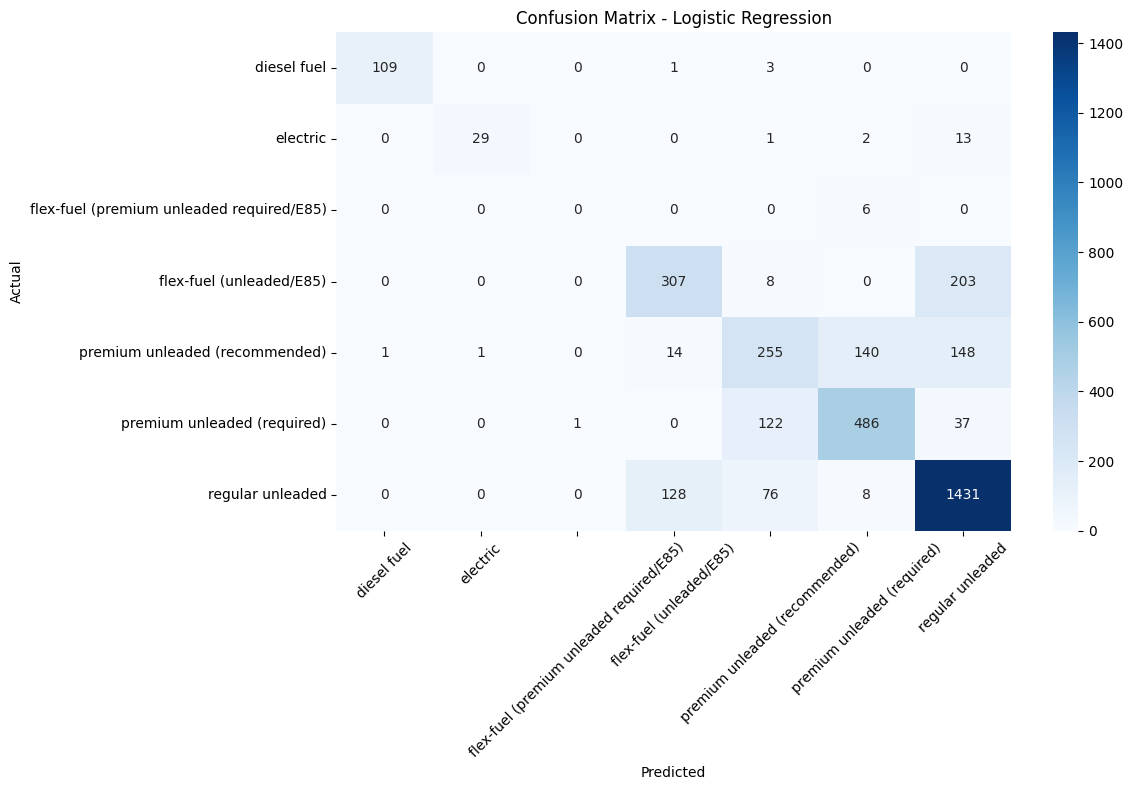



Decision Tree

Accuracy  : 0.9867
Precision : 0.9867
Recall    : 0.9867
F1 Score  : 0.9867

Classification Report

                                           precision    recall  f1-score   support

                              diesel fuel       1.00      1.00      1.00       113
                                 electric       1.00      0.98      0.99        45
flex-fuel (premium unleaded required/E85)       1.00      1.00      1.00         6
                 flex-fuel (unleaded/E85)       1.00      1.00      1.00       518
           premium unleaded (recommended)       0.96      0.97      0.96       559
              premium unleaded (required)       0.97      0.96      0.97       646
                         regular unleaded       1.00      1.00      1.00      1643

                                 accuracy                           0.99      3530
                                macro avg       0.99      0.99      0.99      3530
                             weighted avg       0.9

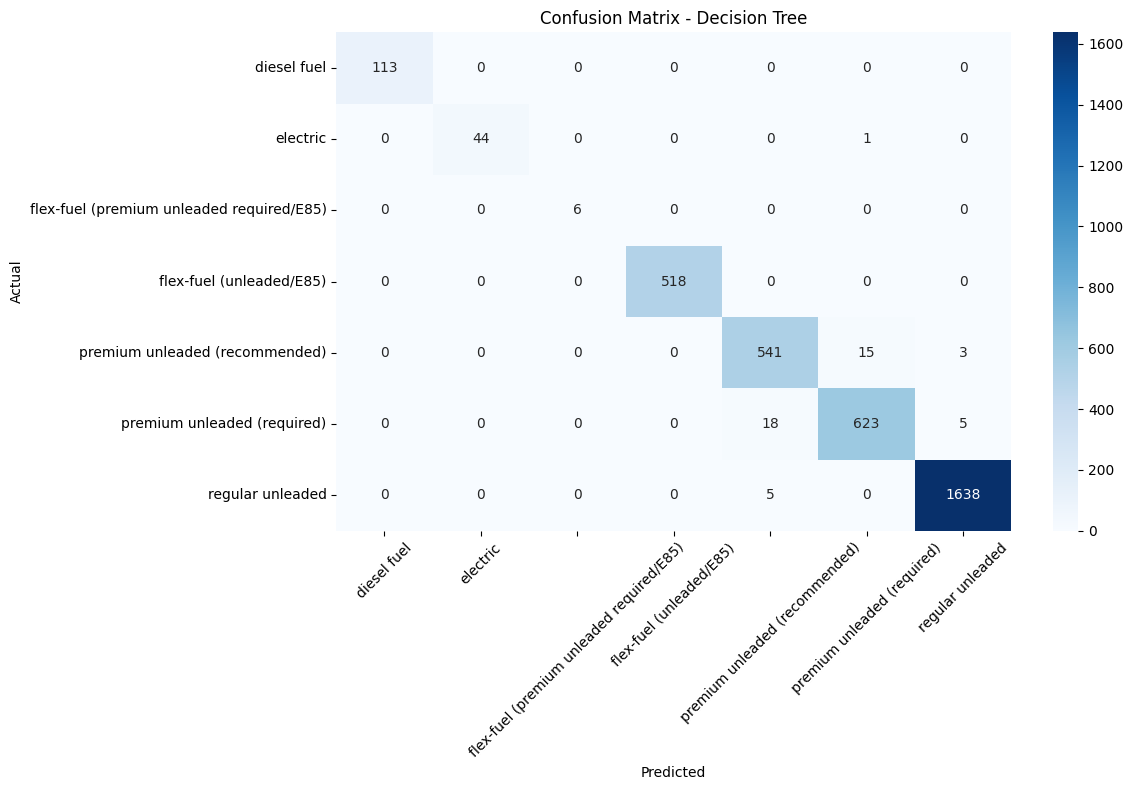



Random Forest

Accuracy  : 0.9966
Precision : 0.9966
Recall    : 0.9966
F1 Score  : 0.9966

Classification Report

                                           precision    recall  f1-score   support

                              diesel fuel       1.00      1.00      1.00       113
                                 electric       1.00      1.00      1.00        45
flex-fuel (premium unleaded required/E85)       1.00      0.83      0.91         6
                 flex-fuel (unleaded/E85)       1.00      1.00      1.00       518
           premium unleaded (recommended)       0.99      0.99      0.99       559
              premium unleaded (required)       0.99      0.99      0.99       646
                         regular unleaded       1.00      1.00      1.00      1643

                                 accuracy                           1.00      3530
                                macro avg       1.00      0.97      0.98      3530
                             weighted avg       1.0

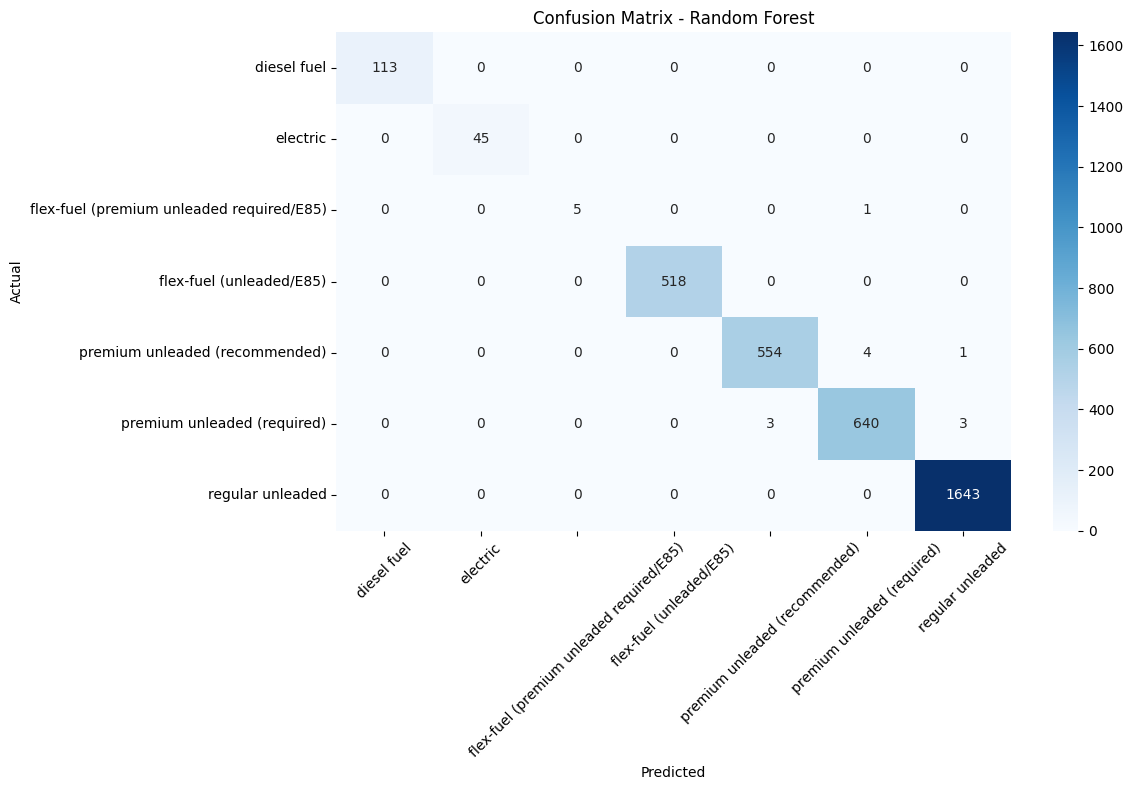



Gradient Boosting

Accuracy  : 0.9674
Precision : 0.9669
Recall    : 0.9674
F1 Score  : 0.9671

Classification Report

                                           precision    recall  f1-score   support

                              diesel fuel       1.00      1.00      1.00       113
                                 electric       1.00      1.00      1.00        45
flex-fuel (premium unleaded required/E85)       0.80      0.67      0.73         6
                 flex-fuel (unleaded/E85)       1.00      1.00      1.00       518
           premium unleaded (recommended)       0.92      0.89      0.90       559
              premium unleaded (required)       0.94      0.93      0.94       646
                         regular unleaded       0.98      1.00      0.99      1643

                                 accuracy                           0.97      3530
                                macro avg       0.95      0.93      0.94      3530
                             weighted avg      

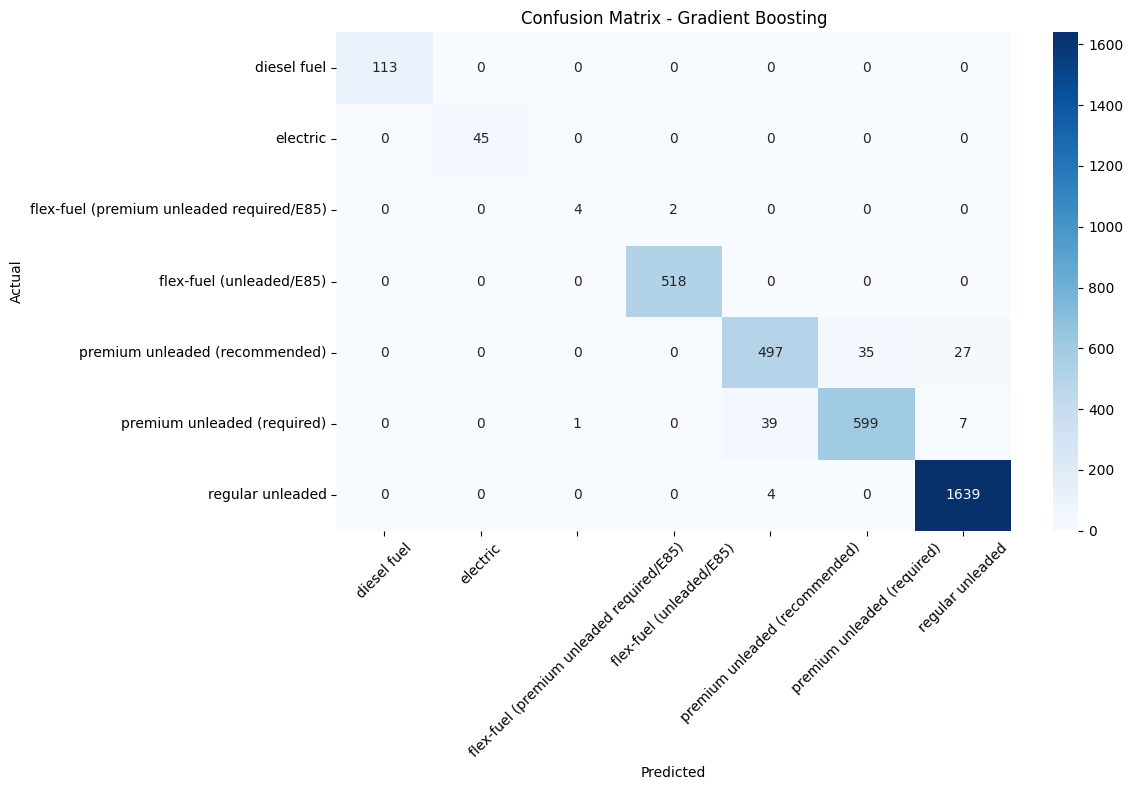



Extra Trees

Accuracy  : 0.9977
Precision : 0.9977
Recall    : 0.9977
F1 Score  : 0.9977

Classification Report

                                           precision    recall  f1-score   support

                              diesel fuel       1.00      1.00      1.00       113
                                 electric       1.00      1.00      1.00        45
flex-fuel (premium unleaded required/E85)       1.00      0.83      0.91         6
                 flex-fuel (unleaded/E85)       1.00      1.00      1.00       518
           premium unleaded (recommended)       0.99      0.99      0.99       559
              premium unleaded (required)       0.99      0.99      0.99       646
                         regular unleaded       1.00      1.00      1.00      1643

                                 accuracy                           1.00      3530
                                macro avg       1.00      0.97      0.99      3530
                             weighted avg       1.00 

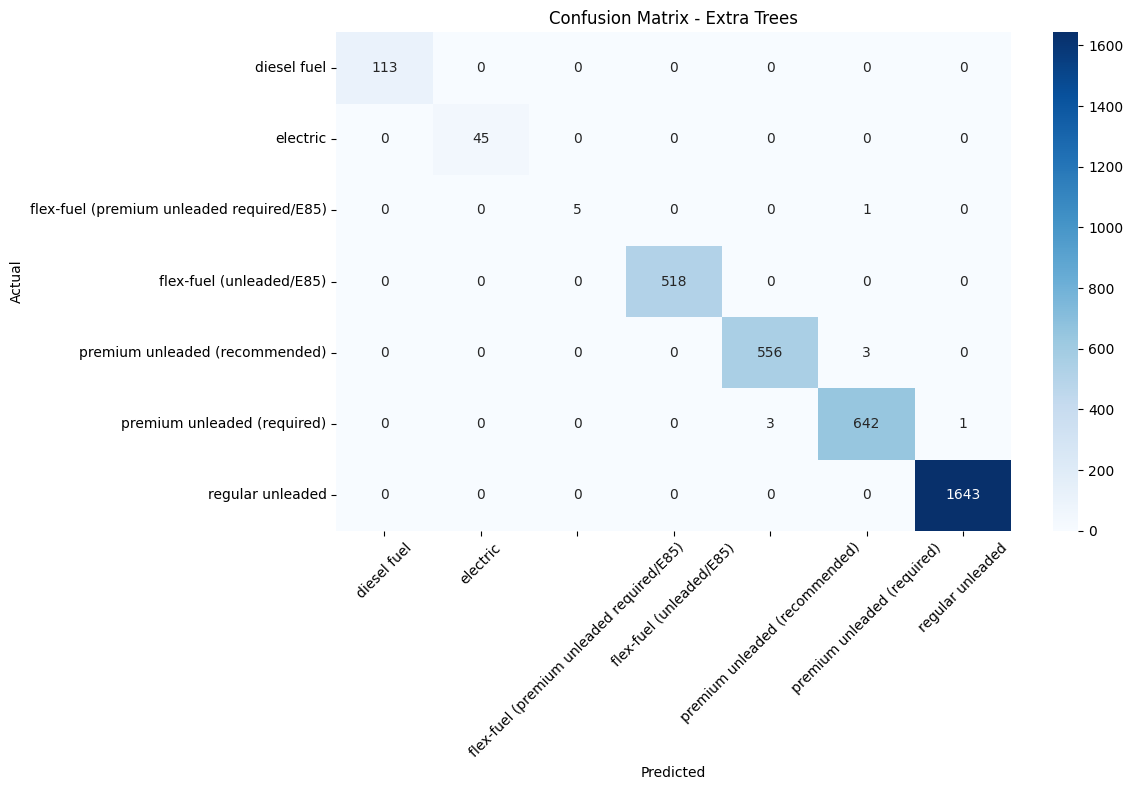



MODEL COMPARISON
                 Model  Accuracy  Precision  Recall     F1
4          Extra Trees     99.77      99.77   99.77  99.77
2        Random Forest     99.66      99.66   99.66  99.66
1        Decision Tree     98.67      98.67   98.67  98.67
3    Gradient Boosting     96.74      96.69   96.74  96.71
0  Logistic Regression     74.14      73.31   74.14  73.45


BEST MODEL
Extra Trees
Accuracy : 99.77 %


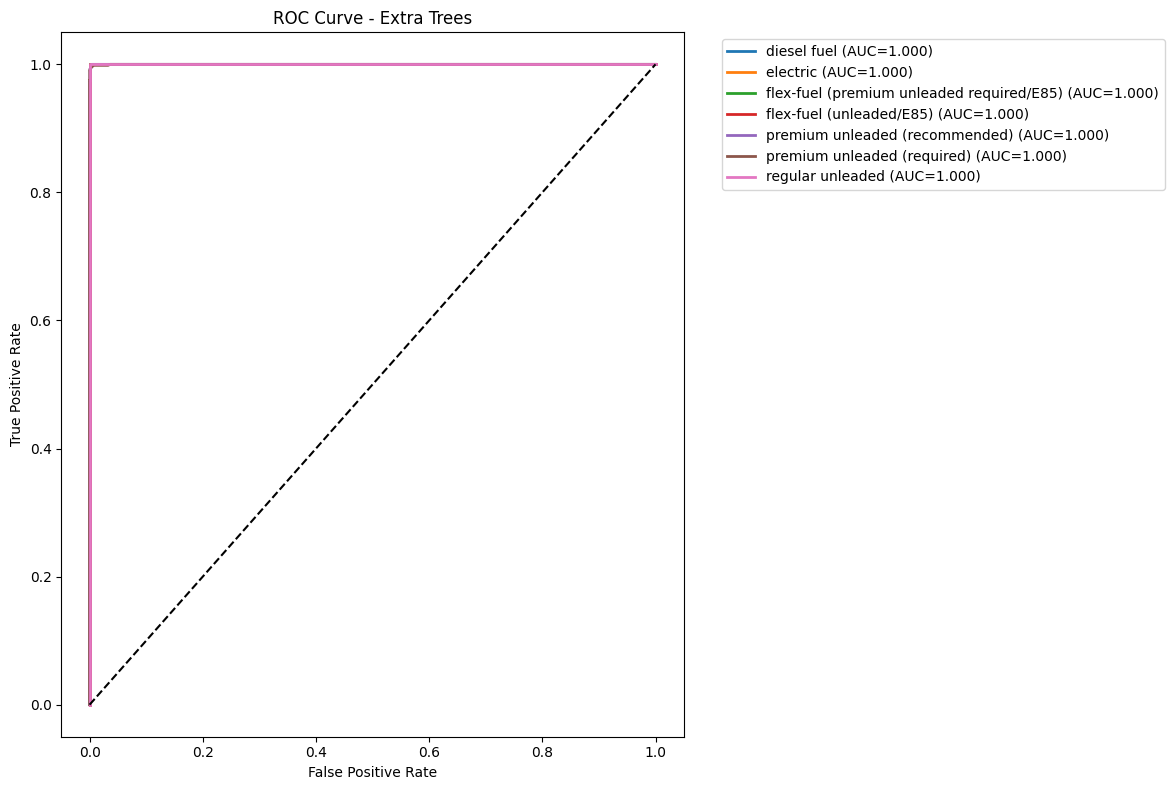



FEATURE IMPORTANCE
                                                Feature  Importance
8543                   cat__Engine Type_flex-fuel (FFV)    0.052113
8544                               cat__Engine Type_gas    0.041382
11                               num__Engine Torque Rpm    0.025777
8                             num__Engine Horsepower Hp    0.019453
10                            num__Engine Torque Ft Lbs    0.017674
18                                     num__Body Height    0.016800
9                            num__Engine Horsepower Rpm    0.015993
7                                      num__Engine Size    0.015597
8541                            cat__Engine Type_diesel    0.015088
0                                          num__Make Id    0.013459
30                      num__Mileage Fuel Tank Capacity    0.012768
4                                        num__Trim Msrp    0.012422
14                                      num__Body Doors    0.012244
8567           cat__Engine 

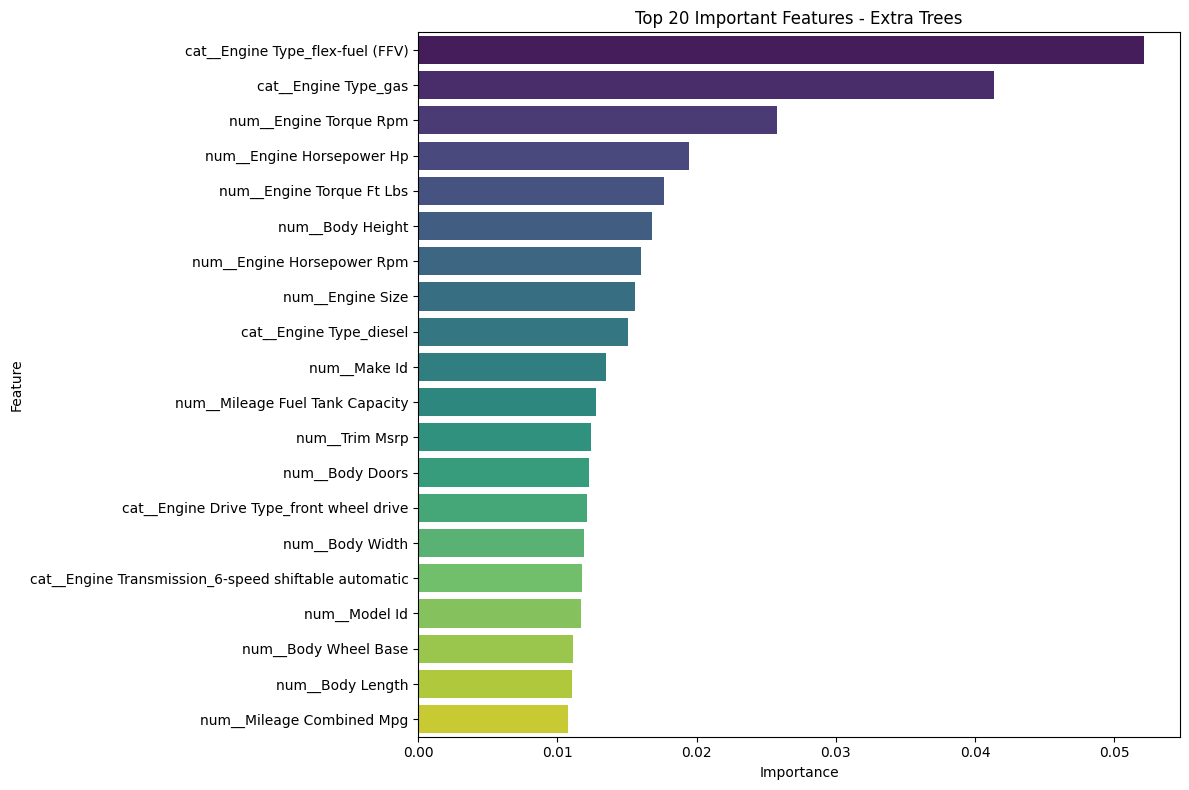



TRAINING COMPLETED SUCCESSFULLY
Results saved as: model_comparison_results.csv


In [16]:
# ==========================================================
# TARGET COLUMN
# ==========================================================

target = "Engine Fuel Type"

# Remove missing target
df = df.dropna(subset=[target])

# ==========================================================
# REMOVE VERY RARE CLASSES
# ==========================================================

fuel_counts = df[target].value_counts()

print("\nFuel Type Distribution")
print(fuel_counts)

# Keep classes with at least 20 samples
valid_classes = fuel_counts[fuel_counts >= 20].index

df = df[df[target].isin(valid_classes)]

print("\nRemaining Classes")
print(df[target].value_counts())

# ==========================================================
# FEATURES AND TARGET
# ==========================================================

X = df.drop(columns=[target])

y = df[target]

# ==========================================================
# LABEL ENCODING TARGET
# ==========================================================

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("\nClasses")

for i, cls in enumerate(le.classes_):
    print(i, ":", cls)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\nTrain Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

# ==========================================================
# FEATURE TYPES
# ==========================================================

cat_cols = X_train.select_dtypes(
    include=["object"]
).columns

num_cols = X_train.select_dtypes(
    exclude=["object"]
).columns

print("\nCategorical Features :", len(cat_cols))
print("Numerical Features   :", len(num_cols))

# ==========================================================
# PREPROCESSING
# ==========================================================

numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),

    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_transformer,
        num_cols
    ),

    (
        "cat",
        categorical_transformer,
        cat_cols
    )
])

# ==========================================================
# MODELS
# ==========================================================

models = {

    "Logistic Regression":
    LogisticRegression(
        max_iter=5000
    ),

    "Decision Tree":
    DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(
        random_state=42
    ),

    "Extra Trees":
    ExtraTreesClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

# Uncomment if XGBoost installed

#    "XGBoost":
#    XGBClassifier(
#        n_estimators=300,
#        learning_rate=0.05,
#        max_depth=8,
#        objective='multi:softprob',
#        eval_metric='mlogloss',
#        random_state=42
#    )

}

# ==========================================================
# MODEL TRAINING
# ==========================================================

results = []

best_accuracy = 0
best_model_name = None
best_pipeline = None

for name, model in models.items():

    print("\n")
    print("="*80)
    print(name)
    print("="*80)

    pipeline = Pipeline([

        (
            "prep",
            preprocessor
        ),

        (
            "model",
            model
        )

    ])

    # TRAIN
    pipeline.fit(
        X_train,
        y_train
    )

    # PREDICT
    y_pred = pipeline.predict(
        X_test
    )

    # METRICS

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print("\nAccuracy  :", round(accuracy,4))
    print("Precision :", round(precision,4))
    print("Recall    :", round(recall,4))
    print("F1 Score  :", round(f1,4))

    # ======================================================
    # CLASSIFICATION REPORT
    # ======================================================

    labels_present = np.unique(
        np.concatenate([y_test, y_pred])
    )

    print("\nClassification Report\n")

    print(

        classification_report(
            y_test,
            y_pred,
            labels=labels_present,
            target_names=le.inverse_transform(
                labels_present
            ),
            zero_division=0
        )

    )

    # ======================================================
    # CONFUSION MATRIX
    # ======================================================

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=labels_present
    )

    plt.figure(figsize=(12,8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=le.inverse_transform(
            labels_present
        ),
        yticklabels=le.inverse_transform(
            labels_present
        )
    )

    plt.title(
        f"Confusion Matrix - {name}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

    # SAVE BEST MODEL

    if accuracy > best_accuracy:

        best_accuracy = accuracy
        best_model_name = name
        best_pipeline = pipeline

# ==========================================================
# MODEL COMPARISON
# ==========================================================

results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df["Accuracy"] *= 100
results_df["Precision"] *= 100
results_df["Recall"] *= 100
results_df["F1"] *= 100

print("\n")
print("="*80)
print("MODEL COMPARISON")
print("="*80)

print(
    results_df.round(2)
)

# ==========================================================
# BEST MODEL
# ==========================================================

print("\n")
print("="*80)
print("BEST MODEL")
print("="*80)

print(best_model_name)
print("Accuracy :", round(best_accuracy*100,2), "%")

# ==========================================================
# ROC CURVE
# ==========================================================

if hasattr(
    best_pipeline.named_steps["model"],
    "predict_proba"
):

    y_score = best_pipeline.predict_proba(
        X_test
    )

    classes_present = np.unique(
        y_test
    )

    y_test_bin = label_binarize(
        y_test,
        classes=classes_present
    )

    score_subset = y_score[
        :,
        classes_present
    ]

    plt.figure(figsize=(12,8))

    for idx, cls in enumerate(
        classes_present
    ):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, idx],
            score_subset[:, idx]
        )

        roc_auc = auc(
            fpr,
            tpr
        )

        plt.plot(
            fpr,
            tpr,
            lw=2,
            label=f"{le.inverse_transform([cls])[0]} "
                  f"(AUC={roc_auc:.3f})"
        )

    plt.plot(
        [0,1],
        [0,1],
        linestyle="--",
        color="black"
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.title(
        f"ROC Curve - {best_model_name}"
    )

    plt.legend(
        bbox_to_anchor=(1.05,1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

if best_model_name in [
    "Random Forest",
    "Extra Trees"
]:

    print("\n")
    print("="*80)
    print("FEATURE IMPORTANCE")
    print("="*80)

    prep = best_pipeline.named_steps[
        "prep"
    ]

    feature_names = (
        prep.get_feature_names_out()
    )

    importances = (
        best_pipeline
        .named_steps["model"]
        .feature_importances_
    )

    feature_df = pd.DataFrame({

        "Feature":
        feature_names,

        "Importance":
        importances

    })

    feature_df = feature_df.sort_values(
        by="Importance",
        ascending=False
    )

    print(
        feature_df.head(20)
    )

    top20 = feature_df.head(20)

    plt.figure(figsize=(12,8))

    sns.barplot(
        data=top20,
        x="Importance",
        y="Feature",
        palette="viridis"
    )

    plt.title(
        f"Top 20 Important Features - {best_model_name}"
    )

    plt.tight_layout()
    plt.show()

# ==========================================================
# SAVE RESULTS
# ==========================================================

results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("\n")
print("="*80)
print("TRAINING COMPLETED SUCCESSFULLY")
print("="*80)
print("Results saved as: model_comparison_results.csv")

## Thank you..pls upvote!!!!!!!!!!!!!!